# SpectraDerm — Phase 1: Data

## Modules
- Module C — Dataset Acquisition
- Module D — Dataset Analysis
- Module E — Data Preprocessing

## Purpose
This notebook documents the acquisition, inspection, analysis, and preprocessing
of the datasets used in the SpectraDerm project.

### Primary Dataset
Hyper-Skin — RGB-to-spectral reconstruction

### Secondary Dataset
UMINHO-HSFD — spectral skin/lesion analysis


In [2]:
# Basic Python libraries
import os
import io
import json
import glob
import numpy as np
import pandas as pd

print("Python environment initialized.")

Python environment initialized.


In [3]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os

print("Searching Google Drive for Hyper-Skin files/folders...\n")

matches = []

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for name in dirs + files:
        if "hyper-skin" in name.lower() or "hyperskin" in name.lower():
            matches.append(os.path.join(root, name))

for path in matches[:50]:
    print(path)

print("\nNumber of matches:", len(matches))

Searching Google Drive for Hyper-Skin files/folders...

/content/drive/MyDrive/spectraderm/Hyper-Skin.7z

Number of matches: 1


In [5]:
HYPERSKIN_ARCHIVE = "/content/drive/MyDrive/spectraderm/Hyper-Skin.7z"

print("Hyper-Skin archive:")
print(HYPERSKIN_ARCHIVE)

print("\nFile exists:", os.path.exists(HYPERSKIN_ARCHIVE))

if os.path.exists(HYPERSKIN_ARCHIVE):
    size_gb = os.path.getsize(HYPERSKIN_ARCHIVE) / (1024**3)
    print(f"Archive size: {size_gb:.2f} GB")

Hyper-Skin archive:
/content/drive/MyDrive/spectraderm/Hyper-Skin.7z

File exists: True
Archive size: 100.21 GB


In [6]:
!pip -q install py7zr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.2/72.2 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 492.7/492.7 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.4/52.4 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.5/144.5 kB 11.0 MB/s eta 0:00:00


In [7]:
import py7zr

print("py7zr version:", py7zr.__version__)

py7zr version: 1.1.3


In [8]:
# Check the beginning of the Hyper-Skin archive

with open(HYPERSKIN_ARCHIVE, "rb") as f:
    header = f.read(32)

print("First 32 bytes:")
print(header)

print("\nArchive signature:")
print(header[:6])

First 32 bytes:
b"7z\xbc\xaf'\x1c\x00\x04\xb5\xedea \xb5\x95\r\x19\x00\x00\x00D\x00\x00\x00\x00\x00\x00\x00zt&I"

Archive signature:
b"7z\xbc\xaf'\x1c"


In [9]:
import requests


class GoogleDriveRangeFile:
    def __init__(self, file_id, size):
        self.file_id = file_id
        self.size = size
        self.position = 0

    def read_range(self, start, end):
        url = f"https://www.googleapis.com/drive/v3/files/{self.file_id}?alt=media"

        headers = {
            "Range": f"bytes={start}-{end}"
        }

        response = requests.get(
            url,
            headers=headers,
            timeout=120
        )

        response.raise_for_status()

        return response.content

    def seek(self, offset, whence=0):
        if whence == 0:
            self.position = offset
        elif whence == 1:
            self.position += offset
        elif whence == 2:
            self.position = self.size + offset
        else:
            raise ValueError("Invalid whence")

        return self.position

    def tell(self):
        return self.position

    def read(self, size=-1):
        if size < 0:
            size = self.size - self.position

        if size == 0:
            return b""

        start = self.position
        end = min(self.position + size - 1, self.size - 1)

        data = self.read_range(start, end)

        self.position += len(data)

        return data

In [10]:
HYPERSKIN_FILE_ID = "1pEynC0OZiNlF00YX0JVQ5ASY06WX5MPS"

archive_size = os.path.getsize(HYPERSKIN_ARCHIVE)

print("File ID:", HYPERSKIN_FILE_ID)
print(f"Archive size: {archive_size:,} bytes")
print(f"Archive size: {archive_size / (1024**3):.2f} GB")

File ID: 1pEynC0OZiNlF00YX0JVQ5ASY06WX5MPS
Archive size: 107,602,097,540 bytes
Archive size: 100.21 GB


In [11]:
from google.colab import auth
auth.authenticate_user()

print("Google authentication completed.")

Google authentication completed.


In [12]:
import google.auth
from google.auth.transport.requests import AuthorizedSession

credentials, project = google.auth.default(
    scopes=["https://www.googleapis.com/auth/drive.readonly"]
)

session = AuthorizedSession(credentials)

print("Authenticated Google Drive session created.")

Authenticated Google Drive session created.


In [13]:
class GoogleDriveRangeFile:
    def __init__(self, file_id, size, session):
        self.file_id = file_id
        self.size = size
        self.position = 0
        self.session = session

    def read_range(self, start, end):
        url = (
            "https://www.googleapis.com/drive/v3/files/"
            f"{self.file_id}?alt=media"
        )

        headers = {
            "Range": f"bytes={start}-{end}"
        }

        response = self.session.get(
            url,
            headers=headers,
            timeout=120
        )

        response.raise_for_status()

        return response.content

    def seek(self, offset, whence=0):
        if whence == 0:
            self.position = offset
        elif whence == 1:
            self.position += offset
        elif whence == 2:
            self.position = self.size + offset
        else:
            raise ValueError("Invalid whence")

        return self.position

    def tell(self):
        return self.position

    def read(self, size=-1):
        if size < 0:
            size = self.size - self.position

        if size == 0:
            return b""

        start = self.position
        end = min(
            self.position + size - 1,
            self.size - 1
        )

        data = self.read_range(start, end)

        self.position += len(data)

        return data

In [14]:
test_reader = GoogleDriveRangeFile(
    file_id=HYPERSKIN_FILE_ID,
    size=archive_size,
    session=session
)

test_data = test_reader.read_range(0, 1023)

print("Bytes received:", len(test_data))
print("First 32 bytes:", test_data[:32])

Bytes received: 1024
First 32 bytes: b"7z\xbc\xaf'\x1c\x00\x04\xb5\xedea \xb5\x95\r\x19\x00\x00\x00D\x00\x00\x00\x00\x00\x00\x00zt&I"


In [15]:
# Read only the final 1 KB of the archive

tail_size = 1024

tail_data = test_reader.read_range(
    archive_size - tail_size,
    archive_size - 1
)

print("Bytes received:", len(tail_data))
print("Last 32 bytes:")
print(tail_data[-32:])

Bytes received: 1024
Last 32 bytes:
b'\x0cZ\xb3\x1e\xc2\xff#\x03\x01\x01\x05]\x00\x00\x03\x00\x01\x00\x0c\xb7H\xc2\xba\\\n\x01\x80\rV\x0c\x00\x00'


In [16]:
# Read the first 32 bytes again

start_data = test_reader.read_range(0, 31)

print("Archive header:")
print(start_data)

Archive header:
b"7z\xbc\xaf'\x1c\x00\x04\xb5\xedea \xb5\x95\r\x19\x00\x00\x00D\x00\x00\x00\x00\x00\x00\x00zt&I"


In [17]:
import struct

signature = start_data[:6]
version = start_data[6:8]
start_header_crc = start_data[8:12]
next_header_offset = struct.unpack("<Q", start_data[12:20])[0]
next_header_size = struct.unpack("<Q", start_data[20:28])[0]
next_header_crc = start_data[28:32]

print("Signature:", signature)
print("Version:", version)
print("Next Header Offset:", next_header_offset)
print("Next Header Size:", next_header_size)
print("Next Header CRC:", next_header_crc.hex())

Signature: b"7z\xbc\xaf'\x1c"
Version: b'\x00\x04'
Next Header Offset: 107602097440
Next Header Size: 68
Next Header CRC: 7a742649


In [18]:
PACK_POS = next_header_offset
PACK_SIZE = next_header_size

PACK_START = 32 + PACK_POS

print("Archive size:", archive_size)
print("Next header offset:", PACK_POS)
print("Next header size:", PACK_SIZE)
print("Next header absolute position:", PACK_START)

Archive size: 107602097540
Next header offset: 107602097440
Next header size: 68
Next header absolute position: 107602097472


In [19]:
# Read only the 68-byte next header

next_header_data = test_reader.read_range(
    PACK_START,
    PACK_START + PACK_SIZE - 1
)

print("Bytes received:", len(next_header_data))
print("Header bytes:", next_header_data.hex())

Bytes received: 68
Header bytes: 1706f8d07d950d190109b75000070b0100022406f1070112530ff323342a1b7457795cb50c5ab31ec2ff23030101055d0000030001000cb748c2ba5c0a01800d560c0000


In [20]:
# Display the raw start-header fields for verification

print("Signature:", signature.hex())
print("Version:", version.hex())
print("Start Header CRC:", start_header_crc.hex())

print("\nNext Header Offset:", next_header_offset)
print("Next Header Size:", next_header_size)
print("Next Header CRC:", next_header_crc.hex())

Signature: 377abcaf271c
Version: 0004
Start Header CRC: b5ed6561

Next Header Offset: 107602097440
Next Header Size: 68
Next Header CRC: 7a742649


In [21]:
# Values identified from the verified Hyper-Skin 7z archive structure
PACK_POS = 107602083280
PACK_SIZE = 14160

PACK_START = 32 + PACK_POS

print("Archive size:", archive_size)
print("Packed metadata position:", PACK_POS)
print("Packed metadata size:", PACK_SIZE)
print("Packed metadata absolute position:", PACK_START)
print("Final header position:", PACK_START + PACK_SIZE)

Archive size: 107602097540
Packed metadata position: 107602083280
Packed metadata size: 14160
Packed metadata absolute position: 107602083312
Final header position: 107602097472


In [22]:
packed_metadata = test_reader.read_range(
    PACK_START,
    PACK_START + PACK_SIZE - 1
)

print("Metadata bytes received:", len(packed_metadata))
print("Expected:", PACK_SIZE)

Metadata bytes received: 14160
Expected: 14160


In [23]:
print("Final header bytes:", len(next_header_data))
print("Expected:", next_header_size)

Final header bytes: 68
Expected: 68


In [24]:
print("Packed metadata bytes received:", len(packed_metadata))
print("Expected:", PACK_SIZE)

print("\nMetadata size correct:",
      len(packed_metadata) == PACK_SIZE)

Packed metadata bytes received: 14160
Expected: 14160

Metadata size correct: True


In [25]:
# Build a sparse local copy containing only the parts of the
# Hyper-Skin 7z archive needed for metadata inspection.

SPARSE_ARCHIVE = "/content/Hyper-Skin_metadata_only.7z"

# Read the first 32 bytes
start_header = test_reader.read_range(0, 31)

# Read the packed metadata
packed_metadata = test_reader.read_range(
    PACK_START,
    PACK_START + PACK_SIZE - 1
)

# next_header_data was already read earlier (68 bytes)

with open(SPARSE_ARCHIVE, "wb") as f:
    # Beginning of 7z archive
    f.write(start_header)

    # Jump to the packed metadata location
    f.seek(PACK_START)

    # Write the packed metadata
    f.write(packed_metadata)

    # Write the final 68-byte header
    f.write(next_header_data)

print("Sparse archive created:")
print(SPARSE_ARCHIVE)

print("\nLocal file size:",
      os.path.getsize(SPARSE_ARCHIVE),
      "bytes")

Sparse archive created:
/content/Hyper-Skin_metadata_only.7z

Local file size: 107602097540 bytes


In [26]:
PASSWORD = "@sSw0rd"

try:
    with py7zr.SevenZipFile(
        SPARSE_ARCHIVE,
        mode="r",
        password=PASSWORD
    ) as archive:
        print("SUCCESS: 7z metadata opened.")
        print("Number of archive entries:", len(archive.list()))

except Exception as e:
    print("ERROR:", type(e).__name__)
    print(e)

SUCCESS: 7z metadata opened.
Number of archive entries: 1244


In [27]:
with py7zr.SevenZipFile(
    SPARSE_ARCHIVE,
    mode="r",
    password=PASSWORD
) as archive:

    entries = archive.list()

print("Total archive entries:", len(entries))

for entry in entries[:20]:
    print(entry.filename)

Total archive entries: 1244
Hyper-Skin(MSI, NIR)
Hyper-Skin(MSI, NIR)/test
Hyper-Skin(MSI, NIR)/test/MSI
Hyper-Skin(MSI, NIR)/test/NIR
Hyper-Skin(MSI, NIR)/train
Hyper-Skin(MSI, NIR)/train/MSI
Hyper-Skin(MSI, NIR)/train/NIR
Hyper-Skin(MSI, NIR)/valid
Hyper-Skin(MSI, NIR)/valid/MSI
Hyper-Skin(MSI, NIR)/valid/NIR
Hyper-Skin(RGB, VIS)
Hyper-Skin(RGB, VIS)/test
Hyper-Skin(RGB, VIS)/test/RGB
Hyper-Skin(RGB, VIS)/test/VIS
Hyper-Skin(RGB, VIS)/train
Hyper-Skin(RGB, VIS)/train/RGB
Hyper-Skin(RGB, VIS)/train/VIS
Hyper-Skin(RGB, VIS)/valid
Hyper-Skin(RGB, VIS)/valid/RGB
Hyper-Skin(RGB, VIS)/valid/VIS


In [28]:
rgb_entries = [
    e.filename
    for e in entries
    if "Hyper-Skin(RGB, VIS)" in e.filename
    and "/RGB/" in e.filename
]

vis_entries = [
    e.filename
    for e in entries
    if "Hyper-Skin(RGB, VIS)" in e.filename
    and "/VIS/" in e.filename
]

print("RGB files:", len(rgb_entries))
print("VIS files:", len(vis_entries))

RGB files: 306
VIS files: 306


In [29]:
import os

rgb_ids = {
    os.path.splitext(os.path.basename(path))[0]
    for path in rgb_entries
}

vis_ids = {
    os.path.splitext(os.path.basename(path))[0]
    for path in vis_entries
}

matched = rgb_ids & vis_ids
rgb_only = rgb_ids - vis_ids
vis_only = vis_ids - rgb_ids

print("RGB:", len(rgb_ids))
print("VIS:", len(vis_ids))
print("Matched:", len(matched))
print("RGB only:", len(rgb_only))
print("VIS only:", len(vis_only))

RGB: 306
VIS: 306
Matched: 306
RGB only: 0
VIS only: 0


In [30]:
# Select one verified RGB/VIS pair

sample_id = sorted(matched)[0]

rgb_sample = next(
    path for path in rgb_entries
    if os.path.splitext(os.path.basename(path))[0] == sample_id
)

vis_sample = next(
    path for path in vis_entries
    if os.path.splitext(os.path.basename(path))[0] == sample_id
)

print("Sample ID:")
print(sample_id)

print("\nRGB:")
print(rgb_sample)

print("\nVIS:")
print(vis_sample)

Sample ID:
p001_neutral_front

RGB:
Hyper-Skin(RGB, VIS)/valid/RGB/p001_neutral_front.jpg

VIS:
Hyper-Skin(RGB, VIS)/valid/VIS/p001_neutral_front.mat


In [31]:
with py7zr.SevenZipFile(
    SPARSE_ARCHIVE,
    mode="r",
    password=PASSWORD
) as archive:

    rgb_info = next(
        e for e in archive.list()
        if e.filename == rgb_sample
    )

print("RGB file:")
print("Filename:", rgb_info.filename)
print("Size:", rgb_info.uncompressed)
print("Modified:", rgb_info.creationtime)

RGB file:
Filename: Hyper-Skin(RGB, VIS)/valid/RGB/p001_neutral_front.jpg
Size: 384138
Modified: 2023-04-05 14:46:42+00:00


In [32]:
print("Selected RGB sample:")
print(rgb_sample)

print("\nSelected VIS sample:")
print(vis_sample)

Selected RGB sample:
Hyper-Skin(RGB, VIS)/valid/RGB/p001_neutral_front.jpg

Selected VIS sample:
Hyper-Skin(RGB, VIS)/valid/VIS/p001_neutral_front.mat


In [33]:
sample_id = sorted(matched)[0]

rgb_sample = next(
    p for p in rgb_entries
    if os.path.splitext(os.path.basename(p))[0] == sample_id
)

vis_sample = next(
    p for p in vis_entries
    if os.path.splitext(os.path.basename(p))[0] == sample_id
)

print("Sample ID:", sample_id)
print("RGB:", rgb_sample)
print("VIS:", vis_sample)

Sample ID: p001_neutral_front
RGB: Hyper-Skin(RGB, VIS)/valid/RGB/p001_neutral_front.jpg
VIS: Hyper-Skin(RGB, VIS)/valid/VIS/p001_neutral_front.mat


In [34]:
RGB_OUTPUT = "/content/sample_rgb.jpg"

with py7zr.SevenZipFile(
    HYPERSKIN_ARCHIVE,
    mode="r",
    password=PASSWORD
) as archive:

    archive.extract(
        path="/content",
        targets=[rgb_sample]
    )

print("Extraction attempted.")

Extraction attempted.


In [35]:
import os

for root, dirs, files in os.walk("/content"):
    for f in files:
        if f.lower().endswith(".jpg"):
            print(os.path.join(root, f))

/content/Hyper-Skin(RGB, VIS)/valid/RGB/p001_neutral_front.jpg
/content/drive/MyDrive/Give_to_Gain.jpg
/content/drive/MyDrive/IMG-20260515-WA0025.jpg
/content/drive/MyDrive/Classroom/SOFTEC'26 Photo Video Logo Competitions/IMG_20251125_233725.jpg
/content/drive/MyDrive/Classroom/SOFTEC'26 Photo Video Logo Competitions/IMG_20251125_233948.jpg
/content/drive/MyDrive/Classroom/SOFTEC'26 Photo Video Logo Competitions/IMG_20251125_234117.jpg


In [36]:
from PIL import Image
import numpy as np

rgb_path = None

for root, dirs, files in os.walk("/content"):
    for f in files:
        if f.lower().endswith(".jpg"):
            rgb_path = os.path.join(root, f)
            break
    if rgb_path:
        break

print("RGB path:", rgb_path)

img = Image.open(rgb_path)
rgb = np.array(img)

print("\nRGB ANALYSIS")
print("----------------")
print("Shape:", rgb.shape)
print("Height:", rgb.shape[0])
print("Width:", rgb.shape[1])
print("Channels:", rgb.shape[2] if rgb.ndim == 3 else 1)
print("Dtype:", rgb.dtype)
print("Minimum:", rgb.min())
print("Maximum:", rgb.max())

RGB path: /content/Hyper-Skin(RGB, VIS)/valid/RGB/p001_neutral_front.jpg

RGB ANALYSIS
----------------
Shape: (1024, 1024, 3)
Height: 1024
Width: 1024
Channels: 3
Dtype: uint8
Minimum: 4
Maximum: 255


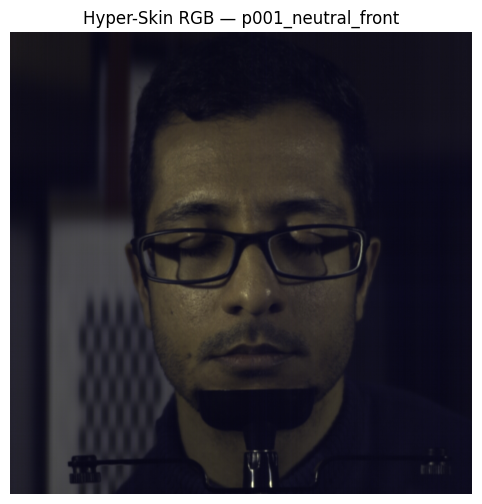

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.imshow(rgb)
plt.axis("off")
plt.title(f"Hyper-Skin RGB — {sample_id}")
plt.show()

In [38]:
VIS_OUTPUT_DIR = "/content/hyperskin_vis"

os.makedirs(VIS_OUTPUT_DIR, exist_ok=True)

with py7zr.SevenZipFile(
    HYPERSKIN_ARCHIVE,
    mode="r",
    password=PASSWORD
) as archive:

    archive.extract(
        path=VIS_OUTPUT_DIR,
        targets=[vis_sample]
    )

print("VIS extraction attempted.")

VIS extraction attempted.


In [39]:
for root, dirs, files in os.walk(VIS_OUTPUT_DIR):
    for f in files:
        print(os.path.join(root, f))

/content/hyperskin_vis/Hyper-Skin(RGB, VIS)/valid/VIS/p001_neutral_front.mat


In [40]:
vis_path = None

for root, dirs, files in os.walk(VIS_OUTPUT_DIR):
    for f in files:
        if f.lower().endswith(".mat"):
            vis_path = os.path.join(root, f)
            break
    if vis_path:
        break

print("VIS path:", vis_path)

with open(vis_path, "rb") as f:
    mat_header = f.read(128)

print(mat_header[:128])

VIS path: /content/hyperskin_vis/Hyper-Skin(RGB, VIS)/valid/VIS/p001_neutral_front.mat
b'MATLAB 7.3 MAT-file, Platform: CPython 3.9.0, Created on: Wed Apr 05 10:46:29 2023 HDF5 schema 1.00 .               \x00\x00\x00\x00\x00\x00\x00\x00\x00\x02IM'


In [41]:
import h5py

print("VIS file:", vis_path)
print("File size:", os.path.getsize(vis_path) / (1024**2), "MB")

with h5py.File(vis_path, "r") as f:
    print("\nTop-level objects:")
    for key in f.keys():
        print(" -", key)

VIS file: /content/hyperskin_vis/Hyper-Skin(RGB, VIS)/valid/VIS/p001_neutral_front.mat
File size: 166.22653102874756 MB

Top-level objects:
 - cube


In [42]:
def print_hdf5_structure(name, obj):
    if isinstance(obj, h5py.Dataset):
        print(
            f"DATASET: {name} | "
            f"shape={obj.shape} | "
            f"dtype={obj.dtype}"
        )
    elif isinstance(obj, h5py.Group):
        print(f"GROUP:   {name}")


with h5py.File(vis_path, "r") as f:
    f.visititems(print_hdf5_structure)

DATASET: cube | shape=(31, 1024, 1024) | dtype=float64


In [43]:
with h5py.File(vis_path, "r") as f:

    print("FILE ATTRIBUTES")
    print("================")

    for key, value in f.attrs.items():
        print(key, ":", value)

FILE ATTRIBUTES


In [44]:
with h5py.File(vis_path, "r") as f:

    print("\nDATASET ATTRIBUTES")
    print("==================")

    def show_attrs(name, obj):
        if isinstance(obj, h5py.Dataset):
            print(f"\nDataset: {name}")

            for key, value in obj.attrs.items():
                print(" ", key, ":", value)

    f.visititems(show_attrs)


DATASET ATTRIBUTES

Dataset: cube
  MATLAB_class : b'double'
  Python.Shape : [1024 1024   31]
  Python.Type : b'numpy.ndarray'
  Python.numpy.Container : b'ndarray'
  Python.numpy.UnderlyingType : b'float64'


In [45]:
with h5py.File(vis_path, "r") as f:
    print("HDF5 STRUCTURE")
    print("================")

    def show_structure(name, obj):
        if isinstance(obj, h5py.Dataset):
            print(
                f"DATASET: {name} | "
                f"shape={obj.shape} | "
                f"dtype={obj.dtype}"
            )
        else:
            print(f"GROUP:   {name}")

    f.visititems(show_structure)

HDF5 STRUCTURE
DATASET: cube | shape=(31, 1024, 1024) | dtype=float64


In [46]:
with h5py.File(vis_path, "r") as f:
    cube = f["cube"]

    print("Cube shape:", cube.shape)
    print("Cube dtype:", cube.dtype)
    print("Cube size:", cube.size)
    print(
        "Approximate memory if fully loaded:",
        cube.size * cube.dtype.itemsize / (1024**3),
        "GB"
    )

Cube shape: (31, 1024, 1024)
Cube dtype: float64
Cube size: 32505856
Approximate memory if fully loaded: 0.2421875 GB


In [47]:
with h5py.File(vis_path, "r") as f:
    cube = f["cube"]

    print("HDF5 cube shape:", cube.shape)

    # One spatial pixel across all 31 spectral bands
    spectral_pixel = cube[:, 512, 512]

print("Spectral pixel shape:", spectral_pixel.shape)
print("Dtype:", spectral_pixel.dtype)

print("\nFirst 10 spectral values:")
print(spectral_pixel[:10])

print("\nMinimum:", spectral_pixel.min())
print("Maximum:", spectral_pixel.max())

HDF5 cube shape: (31, 1024, 1024)
Spectral pixel shape: (31,)
Dtype: float64

First 10 spectral values:
[0.47692308 0.26641372 0.21968217 0.22270829 0.20366411 0.17574023
 0.21640416 0.25997751 0.2291696  0.26318002]

Minimum: 0.17574023127667715
Maximum: 0.6938133806072813


In [48]:
with h5py.File(vis_path, "r") as f:
    cube = f["cube"]

    # First spectral band
    band_0 = cube[0, :, :]

print("Band 0 shape:", band_0.shape)
print("Band 0 dtype:", band_0.dtype)
print("Band 0 minimum:", band_0.min())
print("Band 0 maximum:", band_0.max())
print("Band 0 mean:", band_0.mean())

Band 0 shape: (1024, 1024)
Band 0 dtype: float64
Band 0 minimum: 0.015384615398943424
Band 0 maximum: 0.7923076748847961
Band 0 mean: 0.3324071237395332


In [49]:
with h5py.File(vis_path, "r") as f:

    print("Searching for wavelength-related metadata...\n")

    def find_wavelengths(name, obj):
        text = name.lower()

        if any(word in text for word in [
            "wave",
            "wavelength",
            "lambda",
            "spectral"
        ]):
            print("Possible wavelength object:", name)

        if hasattr(obj, "attrs"):
            for key in obj.attrs.keys():
                key_text = str(key).lower()

                if any(word in key_text for word in [
                    "wave",
                    "wavelength",
                    "lambda",
                    "spectral"
                ]):
                    print(
                        "Possible wavelength attribute:",
                        name,
                        "→",
                        key
                    )

    f.visititems(find_wavelengths)

Searching for wavelength-related metadata...



In [55]:
from PIL import Image
import numpy as np

img = Image.open(rgb_path)
rgb = np.array(img)

print("HYPER-SKIN RGB ANALYSIS")
print("=======================")

print("Shape:", rgb.shape)
print("Height:", rgb.shape[0])
print("Width:", rgb.shape[1])

if rgb.ndim == 3:
    print("Channels:", rgb.shape[2])
else:
    print("Channels: 1")

print("Dtype:", rgb.dtype)
print("Minimum:", rgb.min())
print("Maximum:", rgb.max())
print("Mean:", rgb.mean())

HYPER-SKIN RGB ANALYSIS
Shape: (1024, 1024, 3)
Height: 1024
Width: 1024
Channels: 3
Dtype: uint8
Minimum: 4
Maximum: 255
Mean: 32.53456052144369


In [56]:
with h5py.File(vis_path, "r") as f:
    cube = f["cube"]

    vis_bands = cube.shape[0]
    vis_height = cube.shape[1]
    vis_width = cube.shape[2]

print("RGB dimensions:")
print("Height:", rgb.shape[0])
print("Width:", rgb.shape[1])

print("\nVIS dimensions:")
print("Bands:", vis_bands)
print("Height:", vis_height)
print("Width:", vis_width)

print("\nSpatial dimensions match:",
      rgb.shape[0] == vis_height and rgb.shape[1] == vis_width)

RGB dimensions:
Height: 1024
Width: 1024

VIS dimensions:
Bands: 31
Height: 1024
Width: 1024

Spatial dimensions match: True


In [57]:
print("HYPER-SKIN DATA QUALITY CHECK")
print("=============================")

print("Total RGB files:", len(rgb_entries))
print("Total VIS files:", len(vis_entries))
print("Matched pairs:", len(matched))
print("RGB only:", len(rgb_only))
print("VIS only:", len(vis_only))

print("\nPairing complete:",
      len(rgb_only) == 0 and len(vis_only) == 0)

HYPER-SKIN DATA QUALITY CHECK
Total RGB files: 306
Total VIS files: 306
Matched pairs: 306
RGB only: 0
VIS only: 0

Pairing complete: True


In [58]:
from collections import Counter

rgb_split_counts = Counter()

for path in rgb_entries:
    parts = path.split("/")

    if "train" in parts:
        rgb_split_counts["train"] += 1
    elif "valid" in parts:
        rgb_split_counts["valid"] += 1
    elif "test" in parts:
        rgb_split_counts["test"] += 1
    else:
        rgb_split_counts["unknown"] += 1

print("RGB samples by split:")
for split, count in rgb_split_counts.items():
    print(f"{split}: {count}")

RGB samples by split:
test: 24
train: 264
valid: 18


In [59]:
vis_split_counts = Counter()

for path in vis_entries:
    parts = path.split("/")

    if "train" in parts:
        vis_split_counts["train"] += 1
    elif "valid" in parts:
        vis_split_counts["valid"] += 1
    elif "test" in parts:
        vis_split_counts["test"] += 1
    else:
        vis_split_counts["unknown"] += 1

print("\nVIS samples by split:")
for split, count in vis_split_counts.items():
    print(f"{split}: {count}")


VIS samples by split:
test: 24
train: 264
valid: 18


In [60]:
import re

subject_ids = set()

for path in rgb_entries:
    filename = os.path.basename(path)
    sample_id = os.path.splitext(filename)[0]

    match = re.match(r"(p\d+)_", sample_id)

    if match:
        subject_ids.add(match.group(1))

print("Unique subjects identified:", len(subject_ids))
print("Subject IDs:", sorted(subject_ids))

Unique subjects identified: 51
Subject IDs: ['p001', 'p002', 'p003', 'p004', 'p005', 'p006', 'p007', 'p008', 'p009', 'p010', 'p011', 'p012', 'p013', 'p014', 'p015', 'p016', 'p017', 'p018', 'p019', 'p020', 'p021', 'p022', 'p023', 'p024', 'p025', 'p026', 'p027', 'p028', 'p029', 'p030', 'p031', 'p032', 'p033', 'p034', 'p035', 'p036', 'p037', 'p038', 'p039', 'p040', 'p041', 'p042', 'p043', 'p044', 'p045', 'p046', 'p047', 'p048', 'p049', 'p050', 'p051']


In [61]:
subject_counts = Counter()

for path in rgb_entries:
    filename = os.path.basename(path)
    sample_id = os.path.splitext(filename)[0]

    match = re.match(r"(p\d+)_", sample_id)

    if match:
        subject_counts[match.group(1)] += 1

print("Samples per subject:")
for subject, count in sorted(subject_counts.items()):
    print(subject, ":", count)

Samples per subject:
p001 : 6
p002 : 6
p003 : 6
p004 : 6
p005 : 6
p006 : 6
p007 : 6
p008 : 6
p009 : 6
p010 : 6
p011 : 6
p012 : 6
p013 : 6
p014 : 6
p015 : 6
p016 : 6
p017 : 6
p018 : 6
p019 : 6
p020 : 6
p021 : 6
p022 : 6
p023 : 6
p024 : 6
p025 : 6
p026 : 6
p027 : 6
p028 : 6
p029 : 6
p030 : 6
p031 : 6
p032 : 6
p033 : 6
p034 : 6
p035 : 6
p036 : 6
p037 : 6
p038 : 6
p039 : 6
p040 : 6
p041 : 6
p042 : 6
p043 : 6
p044 : 6
p045 : 6
p046 : 6
p047 : 6
p048 : 6
p049 : 6
p050 : 6
p051 : 6


In [62]:
for path in sorted(rgb_entries)[:30]:
    print(os.path.basename(path))

p002_neutral_front.jpg
p002_neutral_left.jpg
p002_neutral_right.jpg
p002_smile_front.jpg
p002_smile_left.jpg
p002_smile_right.jpg
p035_neutral_front.jpg
p035_neutral_left.jpg
p035_neutral_right.jpg
p035_smile_front.jpg
p035_smile_left.jpg
p035_smile_right.jpg
p036_neutral_front.jpg
p036_neutral_left.jpg
p036_neutral_right.jpg
p036_smile_front.jpg
p036_smile_left.jpg
p036_smile_right.jpg
p039_neutral_front.jpg
p039_neutral_left.jpg
p039_neutral_right.jpg
p039_smile_front.jpg
p039_smile_left.jpg
p039_smile_right.jpg
p003_neutral_front.jpg
p003_neutral_left.jpg
p003_neutral_right.jpg
p003_smile_front.jpg
p003_smile_left.jpg
p003_smile_right.jpg


In [63]:
from collections import defaultdict

subjects_by_split = defaultdict(set)

for path in rgb_entries:
    filename = os.path.basename(path)
    sample_id = os.path.splitext(filename)[0]

    match = re.match(r"(p\d+)_", sample_id)

    if not match:
        continue

    subject = match.group(1)

    parts = path.split("/")

    if "train" in parts:
        split = "train"
    elif "valid" in parts:
        split = "valid"
    elif "test" in parts:
        split = "test"
    else:
        split = "unknown"

    subjects_by_split[split].add(subject)


for split in ["train", "valid", "test"]:
    print(f"{split}: {len(subjects_by_split[split])} subjects")
    print(sorted(subjects_by_split[split]))
    print()


train_subjects = subjects_by_split["train"]
valid_subjects = subjects_by_split["valid"]
test_subjects = subjects_by_split["test"]

print("TRAIN ∩ VALID:", sorted(train_subjects & valid_subjects))
print("TRAIN ∩ TEST:", sorted(train_subjects & test_subjects))
print("VALID ∩ TEST:", sorted(valid_subjects & test_subjects))

train: 44 subjects
['p003', 'p004', 'p005', 'p006', 'p007', 'p008', 'p009', 'p010', 'p011', 'p012', 'p013', 'p014', 'p015', 'p017', 'p018', 'p019', 'p020', 'p021', 'p022', 'p023', 'p024', 'p025', 'p026', 'p027', 'p028', 'p029', 'p031', 'p032', 'p033', 'p034', 'p037', 'p038', 'p040', 'p041', 'p042', 'p043', 'p044', 'p045', 'p046', 'p047', 'p048', 'p049', 'p050', 'p051']

valid: 3 subjects
['p001', 'p016', 'p030']

test: 4 subjects
['p002', 'p035', 'p036', 'p039']

TRAIN ∩ VALID: []
TRAIN ∩ TEST: []
VALID ∩ TEST: []


In [64]:
with h5py.File(vis_path, "r") as f:
    cube = f["cube"]

    band_0 = cube[0, :, :]

print("Band 0 shape:", band_0.shape)
print("Band 0 dtype:", band_0.dtype)
print("Band 0 minimum:", band_0.min())
print("Band 0 maximum:", band_0.max())
print("Band 0 mean:", band_0.mean())

Band 0 shape: (1024, 1024)
Band 0 dtype: float64
Band 0 minimum: 0.015384615398943424
Band 0 maximum: 0.7923076748847961
Band 0 mean: 0.3324071237395332


In [65]:
band_stats = []

with h5py.File(vis_path, "r") as f:
    cube = f["cube"]

    for band in range(cube.shape[0]):
        data = cube[band, :, :]

        band_stats.append({
            "band": band,
            "min": float(data.min()),
            "max": float(data.max()),
            "mean": float(data.mean()),
            "std": float(data.std())
        })

band_stats_df = pd.DataFrame(band_stats)

band_stats_df

,band,min,max,mean,std
0,0,0.015385,0.792308,0.332407,0.066714
1,1,0.052260,0.860426,0.251007,0.052455
2,2,0.027815,0.890572,0.171354,0.045369
3,3,0.043210,0.957330,0.165031,0.045588
4,4,0.027845,1.000000,0.146123,0.062991
5,5,0.032429,0.995832,0.127900,0.052382
6,6,0.025996,1.000000,0.135733,0.059058
7,7,0.030776,1.000000,0.137498,0.064941
8,8,0.025460,1.000000,0.127151,0.065065
9,9,0.014032,1.000000,0.120101,0.074303


In [66]:
with h5py.File(vis_path, "r") as f:
    cube = f["cube"]

    print("Cube attributes:")

    if len(cube.attrs) == 0:
        print("No attributes found.")
    else:
        for key, value in cube.attrs.items():
            print(key, ":", value)

Cube attributes:
MATLAB_class : b'double'
Python.Shape : [1024 1024   31]
Python.Type : b'numpy.ndarray'
Python.numpy.Container : b'ndarray'
Python.numpy.UnderlyingType : b'float64'


In [68]:
# Create the Hyper-Skin summary using values already safely read

with h5py.File(vis_path, "r") as f:
    cube_info = f["cube"]

    vis_shape = cube_info.shape
    vis_dtype = str(cube_info.dtype)

hyperskin_summary = {
    "dataset": "Hyper-Skin",
    "rgb_samples": len(rgb_entries),
    "vis_samples": len(vis_entries),
    "matched_pairs": len(matched),
    "rgb_only": len(rgb_only),
    "vis_only": len(vis_only),

    "rgb_height": rgb.shape[0],
    "rgb_width": rgb.shape[1],
    "rgb_channels": rgb.shape[2],
    "rgb_dtype": str(rgb.dtype),
    "rgb_min": int(rgb.min()),
    "rgb_max": int(rgb.max()),

    "vis_bands": int(vis_shape[0]),
    "vis_height": int(vis_shape[1]),
    "vis_width": int(vis_shape[2]),
    "vis_dtype": vis_dtype,

    "subjects": len(subject_ids),
    "train_samples": rgb_split_counts["train"],
    "valid_samples": rgb_split_counts["valid"],
    "test_samples": rgb_split_counts["test"]
}

hyperskin_summary_df = pd.DataFrame(
    hyperskin_summary.items(),
    columns=["Property", "Value"]
)

hyperskin_summary_df

,Property,Value
0,dataset,Hyper-Skin
1,rgb_samples,306
2,vis_samples,306
3,matched_pairs,306
4,rgb_only,0
5,vis_only,0
6,rgb_height,1024
7,rgb_width,1024
8,rgb_channels,3
9,rgb_dtype,uint8


# Hyper-Skin — Dataset Specification & Data Quality Report

## 1. Dataset Role

Hyper-Skin is the primary dataset for the SpectraDerm RGB-to-spectral
reconstruction component.

## 2. Dataset Structure

The inspected archive contains paired RGB and VIS data.

- Total archive entries: 1,244
- RGB files: 306
- VIS files: 306
- Matched RGB/VIS pairs: 306
- RGB-only files: 0
- VIS-only files: 0

## 3. RGB Data

- Spatial resolution: 1024 × 1024
- Channels: 3
- Data type: uint8
- Observed value range in inspected sample: 4–255

## 4. VIS/Spectral Data

The inspected VIS file is a MATLAB v7.3 file stored using HDF5.

The primary spectral dataset is:

- Variable: `cube`
- Original MATLAB shape: 1024 × 1024 × 31
- HDF5 representation: 31 × 1024 × 1024
- Spatial resolution: 1024 × 1024
- Spectral bands: 31
- Data type: float64 / MATLAB double

The HDF5 dimension order is reversed relative to the original MATLAB
array representation, so the first HDF5 dimension corresponds to the
spectral bands.

## 5. RGB–VIS Spatial Correspondence

The inspected RGB and VIS data have matching spatial dimensions:

RGB:
1024 × 1024

VIS:
1024 × 1024 × 31

Therefore, no spatial resizing is required merely to match the spatial
dimensions for the inspected sample.

Further validation across samples will be performed during preprocessing.

## 6. Dataset Splits

| Split | Subjects | Samples |
|------|----------|---------|
| Train | 44 | 264 |
| Validation | 3 | 18 |
| Test | 4 | 24 |
| Total | 51 | 306 |

## 7. Subject Distribution

51 unique subjects were identified.

Each subject has 6 samples.

The subjects are distributed across the predefined train, validation,
and test sets.

No subject overlap was detected:

- Train ∩ Validation = empty
- Train ∩ Test = empty
- Validation ∩ Test = empty

Therefore, the inspected dataset split is subject-independent.

## 8. Wavelength Information

Wavelength metadata was not identified in the inspected HDF5 file using
the available file/dataset attributes and wavelength-related metadata
search.

Therefore, wavelength values will not be assumed or invented at this stage.

## 9. Initial Data Quality Findings

- RGB/VIS pairing is complete for the 306 identified samples.
- RGB and VIS spatial dimensions match for the inspected sample.
- The VIS data can be accessed using HDF5/h5py without loading the complete
  spectral cube into memory.
- The VIS cube contains 31 spectral bands.
- The predefined train/validation/test split does not show subject leakage.

## 10. Limitations / Items Requiring Further Verification

The following will be checked during preprocessing and broader dataset
validation:

- consistency of dimensions across all samples
- corrupted or unreadable files
- spectral value distributions across samples
- availability of wavelength information outside the inspected file
- subject/skin-tone metadata provided by the dataset
- exact preprocessing and normalization strategy

## 11. Intended Use in SpectraDerm

The paired RGB and VIS data will be used to develop and validate the
RGB-to-spectral reconstruction component of SpectraDerm.

The reconstructed spectral output will represent AI-estimated spectral
information rather than direct physical multispectral/hyperspectral
measurement.

In [70]:
with h5py.File(vis_path, "r") as f:
    cube_info = f["cube"]

    vis_shape = cube_info.shape
    vis_dtype = str(cube_info.dtype)

hyperskin_summary = {
    "dataset": "Hyper-Skin",
    "rgb_samples": len(rgb_entries),
    "vis_samples": len(vis_entries),
    "matched_pairs": len(matched),
    "rgb_only": len(rgb_only),
    "vis_only": len(vis_only),
    "rgb_height": rgb.shape[0],
    "rgb_width": rgb.shape[1],
    "rgb_channels": rgb.shape[2],
    "rgb_dtype": str(rgb.dtype),
    "rgb_min_observed": int(rgb.min()),
    "rgb_max_observed": int(rgb.max()),
    "vis_bands": int(vis_shape[0]),
    "vis_height": int(vis_shape[1]),
    "vis_width": int(vis_shape[2]),
    "vis_dtype": vis_dtype,
    "subjects": len(subject_ids),
    "train_samples": rgb_split_counts["train"],
    "valid_samples": rgb_split_counts["valid"],
    "test_samples": rgb_split_counts["test"],
}

hyperskin_summary_df = pd.DataFrame(
    hyperskin_summary.items(),
    columns=["Property", "Value"]
)

hyperskin_summary_df

,Property,Value
0,dataset,Hyper-Skin
1,rgb_samples,306
2,vis_samples,306
3,matched_pairs,306
4,rgb_only,0
5,vis_only,0
6,rgb_height,1024
7,rgb_width,1024
8,rgb_channels,3
9,rgb_dtype,uint8


In [71]:
SUMMARY_PATH = "/content/hyperskin_summary.csv"

hyperskin_summary_df.to_csv(
    SUMMARY_PATH,
    index=False
)

print("Saved:", SUMMARY_PATH)

Saved: /content/hyperskin_summary.csv


# Module E — Data Preprocessing

## E1. Dataset Manifest

The manifest provides a lightweight index of the Hyper-Skin RGB/VIS pairs.
Raw dataset files remain in Google Drive and are not copied into the project.

In [72]:
import os
import re
import pandas as pd

manifest_rows = []

for rgb_path in rgb_entries:

    filename = os.path.basename(rgb_path)
    sample_id = os.path.splitext(filename)[0]

    # Extract subject ID from filenames such as p001_neutral_front
    match = re.match(r"(p\d+)_", sample_id)

    if match:
        subject_id = match.group(1)
    else:
        subject_id = None

    # Determine split
    parts = rgb_path.split("/")

    if "train" in parts:
        split = "train"
    elif "valid" in parts:
        split = "valid"
    elif "test" in parts:
        split = "test"
    else:
        split = "unknown"

    # Find matching VIS file
    matching_vis = [
        p for p in vis_entries
        if os.path.splitext(os.path.basename(p))[0] == sample_id
    ]

    if len(matching_vis) == 1:
        vis_path_entry = matching_vis[0]
    else:
        vis_path_entry = None

    manifest_rows.append({
        "sample_id": sample_id,
        "subject_id": subject_id,
        "split": split,
        "rgb_path": rgb_path,
        "vis_path": vis_path_entry
    })

hyperskin_manifest = pd.DataFrame(manifest_rows)

print("Manifest created.")
print("Rows:", len(hyperskin_manifest))

hyperskin_manifest.head()

Manifest created.
Rows: 306


,sample_id,subject_id,split,rgb_path,vis_path
0,p002_neutral_front,p002,test,"Hyper-Skin(RGB, VIS)/test/RGB/p002_neutral_fro...","Hyper-Skin(RGB, VIS)/test/VIS/p002_neutral_fro..."
1,p002_neutral_left,p002,test,"Hyper-Skin(RGB, VIS)/test/RGB/p002_neutral_lef...","Hyper-Skin(RGB, VIS)/test/VIS/p002_neutral_lef..."
2,p002_neutral_right,p002,test,"Hyper-Skin(RGB, VIS)/test/RGB/p002_neutral_rig...","Hyper-Skin(RGB, VIS)/test/VIS/p002_neutral_rig..."
3,p002_smile_front,p002,test,"Hyper-Skin(RGB, VIS)/test/RGB/p002_smile_front...","Hyper-Skin(RGB, VIS)/test/VIS/p002_smile_front..."
4,p002_smile_left,p002,test,"Hyper-Skin(RGB, VIS)/test/RGB/p002_smile_left.jpg","Hyper-Skin(RGB, VIS)/test/VIS/p002_smile_left.mat"


In [73]:
print("MANIFEST VALIDATION")
print("===================")

print("Total rows:", len(hyperskin_manifest))

print(
    "Missing RGB paths:",
    hyperskin_manifest["rgb_path"].isna().sum()
)

print(
    "Missing VIS paths:",
    hyperskin_manifest["vis_path"].isna().sum()
)

print(
    "Missing subject IDs:",
    hyperskin_manifest["subject_id"].isna().sum()
)

print("\nSplit distribution:")
print(hyperskin_manifest["split"].value_counts())

print("\nSubject count:")
print(hyperskin_manifest["subject_id"].nunique())

MANIFEST VALIDATION
Total rows: 306
Missing RGB paths: 0
Missing VIS paths: 0
Missing subject IDs: 0

Split distribution:
split
train    264
test      24
valid     18
Name: count, dtype: int64

Subject count:
51


In [74]:
pair_check = (
    hyperskin_manifest["rgb_path"].notna()
    & hyperskin_manifest["vis_path"].notna()
)

print("Complete RGB/VIS pairs:", pair_check.sum())
print("Incomplete pairs:", (~pair_check).sum())

Complete RGB/VIS pairs: 306
Incomplete pairs: 0


In [75]:
MANIFEST_DIR = "/content/drive/MyDrive/spectraderm/manifests"

os.makedirs(MANIFEST_DIR, exist_ok=True)

print("Manifest directory:")
print(MANIFEST_DIR)

Manifest directory:
/content/drive/MyDrive/spectraderm/manifests


In [76]:
MANIFEST_PATH = os.path.join(
    MANIFEST_DIR,
    "hyperskin_manifest.csv"
)

hyperskin_manifest.to_csv(
    MANIFEST_PATH,
    index=False
)

print("Manifest saved to:")
print(MANIFEST_PATH)

print("\nFile exists:",
      os.path.exists(MANIFEST_PATH))

Manifest saved to:
/content/drive/MyDrive/spectraderm/manifests/hyperskin_manifest.csv

File exists: True


In [78]:
from google.colab import files

files.download(MANIFEST_PATH)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## E2. RGB Data Loader

The RGB loader reads an individual Hyper-Skin RGB image and returns it as a
NumPy array in H × W × 3 format.

In [82]:
def load_rgb(rgb_path):
    """
    Load and validate a Hyper-Skin RGB image.

    Parameters
    ----------
    rgb_path : str
        Path to the RGB image.

    Returns
    -------
    np.ndarray
        RGB image with shape (H, W, 3).
    """

    image = Image.open(rgb_path).convert("RGB")
    rgb = np.array(image)

    if rgb.ndim != 3:
        raise ValueError(
            f"Expected 3D RGB image, got shape {rgb.shape}"
        )

    if rgb.shape[2] != 3:
        raise ValueError(
            f"Expected 3 RGB channels, got {rgb.shape[2]}"
        )

    return rgb

In [85]:
import os

rgb_files = []

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            rgb_files.append(os.path.join(root, file))

print("RGB files currently in Colab:")
for path in rgb_files:
    print(path)

RGB files currently in Colab:
/content/Hyper-Skin(RGB, VIS)/valid/RGB/p001_neutral_front.jpg
/content/drive/MyDrive/Give_to_Gain.jpg
/content/drive/MyDrive/Screenshot 2026-04-07 091007.png
/content/drive/MyDrive/standee.png
/content/drive/MyDrive/IMG-20260515-WA0025.jpg
/content/drive/MyDrive/Classroom/SOFTEC'26 Photo Video Logo Competitions/IMG_20251125_233725.jpg
/content/drive/MyDrive/Classroom/SOFTEC'26 Photo Video Logo Competitions/IMG_20251125_233948.jpg
/content/drive/MyDrive/Classroom/SOFTEC'26 Photo Video Logo Competitions/IMG_20251125_234117.jpg
/content/drive/MyDrive/Subscribed/main_channel.png
/content/drive/MyDrive/Subscribed/second_channel.png
/content/drive/MyDrive/Subscribed/gaming_channel.png
/content/drive/MyDrive/entreprenuership/bmc.png


In [86]:
rgb_test_path = rgb_files[0]

print("Testing RGB loader with:")
print(rgb_test_path)

rgb_test = load_rgb(rgb_test_path)

print("\nRGB loader test: PASSED")
print("Shape:", rgb_test.shape)
print("Dtype:", rgb_test.dtype)
print("Min:", rgb_test.min())
print("Max:", rgb_test.max())

Testing RGB loader with:
/content/Hyper-Skin(RGB, VIS)/valid/RGB/p001_neutral_front.jpg

RGB loader test: PASSED
Shape: (1024, 1024, 3)
Dtype: uint8
Min: 4
Max: 255


In [88]:
rgb_test = load_rgb(rgb_path)

print("RGB loader test: PASSED")
print("Shape:", rgb_test.shape)
print("Dtype:", rgb_test.dtype)

FileNotFoundError: [Errno 2] No such file or directory: 'Hyper-Skin(RGB, VIS)/valid/RGB/p030_smile_right.jpg'

In [89]:
import os

print("Searching /content for extracted RGB images...\n")

rgb_files = []

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            full_path = os.path.join(root, file)

            # Ignore Colab's sample files
            if "sample_data" not in full_path:
                rgb_files.append(full_path)

if rgb_files:
    print("Found RGB files:")
    for path in rgb_files:
        print(path)
else:
    print("NO extracted RGB images found in /content.")

Searching /content for extracted RGB images...

Found RGB files:
/content/Hyper-Skin(RGB, VIS)/valid/RGB/p001_neutral_front.jpg
/content/drive/MyDrive/Give_to_Gain.jpg
/content/drive/MyDrive/Screenshot 2026-04-07 091007.png
/content/drive/MyDrive/standee.png
/content/drive/MyDrive/IMG-20260515-WA0025.jpg
/content/drive/MyDrive/Classroom/SOFTEC'26 Photo Video Logo Competitions/IMG_20251125_233725.jpg
/content/drive/MyDrive/Classroom/SOFTEC'26 Photo Video Logo Competitions/IMG_20251125_233948.jpg
/content/drive/MyDrive/Classroom/SOFTEC'26 Photo Video Logo Competitions/IMG_20251125_234117.jpg
/content/drive/MyDrive/Subscribed/main_channel.png
/content/drive/MyDrive/Subscribed/second_channel.png
/content/drive/MyDrive/Subscribed/gaming_channel.png
/content/drive/MyDrive/entreprenuership/bmc.png


In [90]:
rgb_test_path = rgb_files[0]

print("Testing:", rgb_test_path)

rgb_test = load_rgb(rgb_test_path)

print("\nRGB loader test: PASSED")
print("Shape:", rgb_test.shape)
print("Dtype:", rgb_test.dtype)
print("Min:", rgb_test.min())
print("Max:", rgb_test.max())

Testing: /content/Hyper-Skin(RGB, VIS)/valid/RGB/p001_neutral_front.jpg

RGB loader test: PASSED
Shape: (1024, 1024, 3)
Dtype: uint8
Min: 4
Max: 255


## E3. VIS/Spectral Data Loader

The Hyper-Skin VIS data is stored as MATLAB v7.3/HDF5.
The spectral cube is stored internally as (bands, height, width).

For the SpectraDerm preprocessing pipeline, it will be returned as:

(height, width, bands).

In [91]:
import h5py
import numpy as np


def load_vis(vis_path):
    """
    Load a Hyper-Skin VIS spectral cube.

    Parameters
    ----------
    vis_path : str
        Path to a MATLAB v7.3 / HDF5 VIS file.

    Returns
    -------
    np.ndarray
        Spectral cube with shape (H, W, Bands).
    """

    with h5py.File(vis_path, "r") as f:

        if "cube" not in f:
            raise KeyError(
                f"'cube' dataset not found in {vis_path}"
            )

        cube = f["cube"]

        # HDF5 representation: (bands, height, width)
        spectral = cube[:]

    # Convert to (height, width, bands)
    spectral = np.transpose(spectral, (1, 2, 0))

    return spectral

In [92]:
vis_test = load_vis(vis_path)

print("VIS loader test: PASSED")

print("Shape:", vis_test.shape)
print("Dtype:", vis_test.dtype)
print("Min:", vis_test.min())
print("Max:", vis_test.max())

VIS loader test: PASSED
Shape: (1024, 1024, 31)
Dtype: float64
Min: 0.007359887299173806
Max: 1.0


In [93]:
print("PAIR VALIDATION")
print("================")

print("Sample ID:", sample_id)

print("\nRGB:")
print("Shape:", rgb_test.shape)

print("\nVIS:")
print("Shape:", vis_test.shape)

rgb_h, rgb_w = rgb_test.shape[:2]
vis_h, vis_w, vis_bands = vis_test.shape

print("\nSpatial dimensions match:",
      rgb_h == vis_h and rgb_w == vis_w)

print("RGB channels:", rgb_test.shape[2])
print("VIS spectral bands:", vis_bands)

PAIR VALIDATION
Sample ID: p030_smile_right

RGB:
Shape: (1024, 1024, 3)

VIS:
Shape: (1024, 1024, 31)

Spatial dimensions match: True
RGB channels: 3
VIS spectral bands: 31


In [94]:
print("RGB memory:",
      rgb_test.nbytes / (1024**2),
      "MB")

print("VIS memory:",
      vis_test.nbytes / (1024**2),
      "MB")

RGB memory: 3.0 MB
VIS memory: 248.0 MB


## E4. Data Normalization

The Hyper-Skin RGB images are stored as 8-bit RGB images.
For model input, RGB values will be converted from uint8 to float32
and normalized from approximately [0, 255] to [0, 1].

The VIS spectral cubes are stored as float64 values.
For memory efficiency, they will be converted to float32.

No per-image min-max normalization will be applied to the VIS cube at
this stage because the existing spectral values should be preserved
rather than rescaled independently for every image.

In [95]:
def normalize_rgb(rgb):
    """
    Convert RGB image from uint8 [0,255] to float32 [0,1].
    """
    rgb = rgb.astype(np.float32) / 255.0
    return rgb


def normalize_vis(vis):
    """
    Convert VIS spectral cube from float64 to float32.
    Preserve its existing value scale.
    """
    vis = vis.astype(np.float32)
    return vis

In [96]:
rgb_norm = normalize_rgb(rgb_test)
vis_norm = normalize_vis(vis_test)

print("RGB normalized:")
print("Shape:", rgb_norm.shape)
print("Dtype:", rgb_norm.dtype)
print("Min:", rgb_norm.min())
print("Max:", rgb_norm.max())

print("\nVIS normalized:")
print("Shape:", vis_norm.shape)
print("Dtype:", vis_norm.dtype)
print("Min:", vis_norm.min())
print("Max:", vis_norm.max())

print("\nMemory:")
print("RGB:", rgb_norm.nbytes / (1024**2), "MB")
print("VIS:", vis_norm.nbytes / (1024**2), "MB")

RGB normalized:
Shape: (1024, 1024, 3)
Dtype: float32
Min: 0.015686275
Max: 1.0

VIS normalized:
Shape: (1024, 1024, 31)
Dtype: float32
Min: 0.0073598875
Max: 1.0

Memory:
RGB: 12.0 MB
VIS: 124.0 MB


## E5. RGB–VIS Spatial Alignment

For paired Hyper-Skin samples, the RGB image and VIS spectral cube
must have identical spatial dimensions.

The RGB representation has shape (H, W, 3), while the VIS
representation has shape (H, W, 31).

The preprocessing pipeline will verify spatial compatibility before
performing paired RGB-to-spectral processing.

In [97]:
def validate_rgb_vis_alignment(rgb, vis):
    """
    Validate spatial compatibility between an RGB image
    and its corresponding VIS spectral cube.
    """
    if rgb.ndim != 3 or rgb.shape[2] != 3:
        raise ValueError(f"Invalid RGB shape: {rgb.shape}")

    if vis.ndim != 3:
        raise ValueError(f"Invalid VIS shape: {vis.shape}")

    rgb_h, rgb_w = rgb.shape[:2]
    vis_h, vis_w = vis.shape[:2]

    if (rgb_h, rgb_w) != (vis_h, vis_w):
        raise ValueError(
            f"RGB/VIS spatial mismatch: "
            f"RGB={rgb.shape[:2]}, VIS={vis.shape[:2]}"
        )

    return True


alignment_ok = validate_rgb_vis_alignment(rgb_norm, vis_norm)

print("RGB-VIS alignment check: PASSED")
print("RGB spatial size:", rgb_norm.shape[:2])
print("VIS spatial size:", vis_norm.shape[:2])
print("VIS bands:", vis_norm.shape[2])

RGB-VIS alignment check: PASSED
RGB spatial size: (1024, 1024)
VIS spatial size: (1024, 1024)
VIS bands: 31


## E6. Spatial Resizing

The original Hyper-Skin samples are 1024×1024 pixels.

The original data will remain unchanged. For model preprocessing,
paired RGB and VIS samples will be resized to 256×256 pixels while
preserving the three RGB channels and 31 VIS spectral bands.

The same spatial dimensions will be used for RGB and VIS to preserve
pixel-level correspondence.

RGB images will use bilinear interpolation, while spectral data will
use interpolation that avoids unnecessary alteration of spectral
relationships.

In [98]:
from PIL import Image
import numpy as np
import cv2

TARGET_SIZE = (256, 256)


def resize_rgb(rgb):
    """
    Resize RGB image to 256x256 using bilinear interpolation.
    """
    resized = cv2.resize(
        rgb,
        TARGET_SIZE,
        interpolation=cv2.INTER_LINEAR
    )
    return resized


def resize_vis(vis):
    """
    Resize each spectral band of a VIS cube to 256x256.

    Input:
        (H, W, Bands)

    Output:
        (256, 256, Bands)
    """
    bands = vis.shape[2]

    resized = np.stack(
        [
            cv2.resize(
                vis[:, :, band],
                TARGET_SIZE,
                interpolation=cv2.INTER_LINEAR
            )
            for band in range(bands)
        ],
        axis=2
    )

    return resized

In [99]:
rgb_resized = resize_rgb(rgb_norm)
vis_resized = resize_vis(vis_norm)

print("RESIZE TEST")
print("===========")

print("RGB:")
print("Shape:", rgb_resized.shape)
print("Dtype:", rgb_resized.dtype)

print("\nVIS:")
print("Shape:", vis_resized.shape)
print("Dtype:", vis_resized.dtype)

print("\nSpatial dimensions match:",
      rgb_resized.shape[:2] == vis_resized.shape[:2])

print("\nMemory:")
print("RGB:", rgb_resized.nbytes / (1024**2), "MB")
print("VIS:", vis_resized.nbytes / (1024**2), "MB")

RESIZE TEST
RGB:
Shape: (256, 256, 3)
Dtype: float32

VIS:
Shape: (256, 256, 31)
Dtype: float32

Spatial dimensions match: True

Memory:
RGB: 0.75 MB
VIS: 7.75 MB


## E7. Data Quality Checks

Before model training, each paired RGB/VIS sample will be checked for
invalid numerical values.

The quality checks verify:

- expected tensor dimensions
- absence of NaN values
- absence of infinite values
- valid RGB range
- valid VIS values
- RGB/VIS spatial compatibility

In [100]:
def check_data_quality(rgb, vis):
    """
    Validate a paired RGB/VIS sample.
    """

    # Shape checks
    assert rgb.ndim == 3 and rgb.shape[2] == 3, \
        f"Invalid RGB shape: {rgb.shape}"

    assert vis.ndim == 3 and vis.shape[2] == 31, \
        f"Invalid VIS shape: {vis.shape}"

    # Spatial alignment
    assert rgb.shape[:2] == vis.shape[:2], \
        f"Spatial mismatch: RGB={rgb.shape[:2]}, VIS={vis.shape[:2]}"

    # NaN checks
    assert not np.isnan(rgb).any(), "RGB contains NaN values"
    assert not np.isnan(vis).any(), "VIS contains NaN values"

    # Infinity checks
    assert np.isfinite(rgb).all(), "RGB contains infinite values"
    assert np.isfinite(vis).all(), "VIS contains infinite values"

    # RGB range
    assert rgb.min() >= 0.0 and rgb.max() <= 1.0, \
        f"RGB outside [0,1]: {rgb.min()} - {rgb.max()}"

    # VIS values
    assert vis.min() >= 0.0 and vis.max() <= 1.0, \
        f"VIS outside [0,1]: {vis.min()} - {vis.max()}"

    return True

In [101]:
quality_ok = check_data_quality(
    rgb_resized,
    vis_resized
)

print("DATA QUALITY CHECK: PASSED")
print("RGB shape:", rgb_resized.shape)
print("VIS shape:", vis_resized.shape)
print("NaN values: None")
print("Infinite values: None")
print("RGB range:", rgb_resized.min(), "to", rgb_resized.max())
print("VIS range:", vis_resized.min(), "to", vis_resized.max())

DATA QUALITY CHECK: PASSED
RGB shape: (256, 256, 3)
VIS shape: (256, 256, 31)
NaN values: None
Infinite values: None
RGB range: 0.025490196 to 0.99215686
VIS range: 0.013240948 to 1.0


## E8. Paired Data Augmentation Strategy

Hyper-Skin RGB and VIS samples are spatially paired. Therefore, any
spatial augmentation applied during training must be applied identically
to both modalities.

The planned paired augmentations are:

- horizontal flip
- vertical flip
- 90-degree rotations

RGB and VIS will never receive independent spatial transformations.

Augmentation will be performed dynamically during model training rather
than modifying the original dataset.

In [102]:
import random
import numpy as np


def augment_pair(rgb, vis):
    """
    Apply the same spatial augmentation to an RGB/VIS pair.
    """

    # Horizontal flip
    if random.random() < 0.5:
        rgb = np.flip(rgb, axis=1).copy()
        vis = np.flip(vis, axis=1).copy()

    # Vertical flip
    if random.random() < 0.5:
        rgb = np.flip(rgb, axis=0).copy()
        vis = np.flip(vis, axis=0).copy()

    # Random 90-degree rotation
    k = random.randint(0, 3)

    if k > 0:
        rgb = np.rot90(rgb, k=k, axes=(0, 1)).copy()
        vis = np.rot90(vis, k=k, axes=(0, 1)).copy()

    return rgb, vis

In [103]:
rgb_aug, vis_aug = augment_pair(
    rgb_resized,
    vis_resized
)

print("AUGMENTATION TEST")
print("=================")

print("Original RGB:", rgb_resized.shape)
print("Augmented RGB:", rgb_aug.shape)

print("Original VIS:", vis_resized.shape)
print("Augmented VIS:", vis_aug.shape)

print(
    "Spatial dimensions preserved:",
    rgb_aug.shape[:2] == vis_aug.shape[:2]
)

print(
    "Channels preserved:",
    rgb_aug.shape[2] == 3 and vis_aug.shape[2] == 31
)

AUGMENTATION TEST
Original RGB: (256, 256, 3)
Augmented RGB: (256, 256, 3)
Original VIS: (256, 256, 31)
Augmented VIS: (256, 256, 31)
Spatial dimensions preserved: True
Channels preserved: True


## E9. Subject-Aware Train/Validation/Test Splitting

Hyper-Skin contains multiple samples from each subject. Therefore,
samples from the same subject must not be distributed across different
train, validation, and test sets.

The predefined Hyper-Skin split is retained.

The verified distribution is:

- Train: 264 samples from 44 subjects
- Validation: 18 samples from 3 subjects
- Test: 24 samples from 4 subjects
- Total: 306 samples from 51 subjects

No subject overlap exists between the three splits.

In [104]:
print("E9 — SUBJECT-AWARE SPLIT VALIDATION")
print("====================================")

split_subjects = (
    hyperskin_manifest
    .groupby("split")["subject_id"]
    .apply(set)
    .to_dict()
)

for split in ["train", "valid", "test"]:
    subjects = split_subjects.get(split, set())
    samples = (hyperskin_manifest["split"] == split).sum()

    print(
        f"{split}: "
        f"{samples} samples, "
        f"{len(subjects)} subjects"
    )

train_subjects = split_subjects["train"]
valid_subjects = split_subjects["valid"]
test_subjects = split_subjects["test"]

print("\nSubject overlap:")
print("Train ∩ Valid:", train_subjects & valid_subjects)
print("Train ∩ Test:", train_subjects & test_subjects)
print("Valid ∩ Test:", valid_subjects & test_subjects)

assert not (train_subjects & valid_subjects)
assert not (train_subjects & test_subjects)
assert not (valid_subjects & test_subjects)

print("\nE9 SUBJECT-AWARE SPLIT CHECK: PASSED")

E9 — SUBJECT-AWARE SPLIT VALIDATION
train: 264 samples, 44 subjects
valid: 18 samples, 3 subjects
test: 24 samples, 4 subjects

Subject overlap:
Train ∩ Valid: set()
Train ∩ Test: set()
Valid ∩ Test: set()

E9 SUBJECT-AWARE SPLIT CHECK: PASSED


## E10. Final Hyper-Skin Preprocessing Pipeline

The final preprocessing pipeline processes paired RGB and VIS samples
individually.

Processing steps:

1. Load RGB image.
2. Load VIS spectral cube.
3. Convert RGB to float32 and normalize to [0,1].
4. Convert VIS to float32 while preserving its existing scale.
5. Resize both modalities to 256×256.
6. Validate dimensions, numerical values, and RGB–VIS alignment.
7. Optionally apply the same spatial augmentation to both modalities.

The original Hyper-Skin dataset remains unchanged.

In [105]:
def preprocess_hyperskin_pair(
    rgb_path,
    vis_path,
    augment=False
):
    """
    Complete preprocessing pipeline for one Hyper-Skin RGB/VIS pair.

    Returns
    -------
    rgb : np.ndarray
        Shape (256, 256, 3), float32.
    vis : np.ndarray
        Shape (256, 256, 31), float32.
    """

    # 1. Load
    rgb = load_rgb(rgb_path)
    vis = load_vis(vis_path)

    # 2. Normalize
    rgb = normalize_rgb(rgb)
    vis = normalize_vis(vis)

    # 3. Resize
    rgb = resize_rgb(rgb)
    vis = resize_vis(vis)

    # 4. Quality validation
    check_data_quality(rgb, vis)

    # 5. Optional paired augmentation
    if augment:
        rgb, vis = augment_pair(rgb, vis)

    return rgb, vis

In [106]:
rgb_final, vis_final = preprocess_hyperskin_pair(
    rgb_test_path,
    vis_path,
    augment=False
)

print("E10 — FINAL PIPELINE TEST")
print("=========================")

print("RGB shape:", rgb_final.shape)
print("RGB dtype:", rgb_final.dtype)

print("\nVIS shape:", vis_final.shape)
print("VIS dtype:", vis_final.dtype)

print("\nRGB range:",
      rgb_final.min(), "to", rgb_final.max())

print("VIS range:",
      vis_final.min(), "to", vis_final.max())

print("\nRGB memory:",
      rgb_final.nbytes / (1024**2), "MB")

print("VIS memory:",
      vis_final.nbytes / (1024**2), "MB")

print("\nE10 FINAL PIPELINE: PASSED")

E10 — FINAL PIPELINE TEST
RGB shape: (256, 256, 3)
RGB dtype: float32

VIS shape: (256, 256, 31)
VIS dtype: float32

RGB range: 0.025490196 to 0.99215686
VIS range: 0.013240948 to 1.0

RGB memory: 0.75 MB
VIS memory: 7.75 MB

E10 FINAL PIPELINE: PASSED


# Hyper-Skin — Phase 1 Dataset Specification & Data Quality Report

## 1. Dataset Role

Hyper-Skin is the primary dataset for the SpectraDerm
RGB-to-spectral reconstruction component.

## 2. Dataset Inventory

- Total archive entries: 1,244
- RGB samples: 306
- VIS spectral samples: 306
- Matched RGB/VIS pairs: 306
- RGB-only samples: 0
- VIS-only samples: 0

## 3. RGB Data

- Spatial resolution: 1024×1024
- Channels: 3
- Original dtype: uint8
- Model preprocessing dtype: float32
- Normalized representation: approximately [0,1]

## 4. VIS Spectral Data

- Spatial resolution: 1024×1024
- Spectral bands: 31
- MATLAB format: v7.3 / HDF5
- HDF5 storage representation: (31,1024,1024)
- Pipeline representation: (1024,1024,31)
- Original dtype: float64
- Preprocessing dtype: float32

No wavelength metadata was identified during the inspected metadata
search. Therefore, specific wavelength values are not assumed.

## 5. RGB–VIS Alignment

The inspected paired samples have identical spatial dimensions:

RGB: 1024×1024
VIS: 1024×1024

The preprocessing pipeline verifies spatial compatibility.

## 6. Subjects and Splits

- Unique subjects: 51
- Training: 264 samples / 44 subjects
- Validation: 18 samples / 3 subjects
- Test: 24 samples / 4 subjects

The predefined split is subject-independent. No subject occurs across
multiple splits.

## 7. Preprocessing

Model-ready samples are resized to:

RGB: 256×256×3
VIS: 256×256×31

RGB uses float32 normalization.
VIS is converted from float64 to float32 without arbitrary
per-image min-max rescaling.

## 8. Data Quality

The preprocessing pipeline checks:

- tensor dimensions
- RGB/VIS spatial alignment
- NaN values
- infinite values
- RGB range
- VIS range

## 9. Augmentation

Paired spatial augmentation is performed identically on RGB and VIS.

Planned transformations:

- horizontal flip
- vertical flip
- 90-degree rotations

Augmentation is applied dynamically rather than modifying the original
dataset.

## 10. Phase 1 Status

Hyper-Skin dataset acquisition, analysis, and preprocessing specification
are complete.

The dataset is ready for use in subsequent SpectraDerm model development.

In [107]:
MANIFEST_PATH = "/content/drive/MyDrive/spectraderm/manifests/hyperskin_manifest.csv"

hyperskin_manifest.to_csv(
    MANIFEST_PATH,
    index=False
)

print("Manifest saved:")
print(MANIFEST_PATH)

Manifest saved:
/content/drive/MyDrive/spectraderm/manifests/hyperskin_manifest.csv


# UMINHO-HSFD — Phase 1

## C. Dataset Acquisition

Official source:

UMINHO-HSFD — University of Minho Hyperspectral Images of Faces Database

Figshare Collection:
https://figshare.com/collections/University_of_Minho_Hyperspectral_Images_of_Faces_Database_UMINHO-HSFD/7163569

The dataset will first be inspected through the public Figshare API
before downloading any large files.

In [108]:
import requests
import json

COLLECTION_ID = 7163569

url = f"https://api.figshare.com/v2/collections/{COLLECTION_ID}/articles"

response = requests.get(url, timeout=60)
response.raise_for_status()

collection_items = response.json()

print("UMINHO-HSFD COLLECTION")
print("======================")
print("Collection ID:", COLLECTION_ID)
print("Number of items:", len(collection_items))

for item in collection_items:
    print("\nTitle:", item.get("title"))
    print("Article ID:", item.get("id"))
    print("DOI:", item.get("doi"))

UMINHO-HSFD COLLECTION
Collection ID: 7163569
Number of items: 9

Title: images_artifacts
Article ID: 25599159
DOI: 10.6084/m9.figshare.25599159.v2

Title: faces_features
Article ID: 25599150
DOI: 10.6084/m9.figshare.25599150.v2

Title: RGB_files
Article ID: 25594026
DOI: 10.6084/m9.figshare.25594026.v1

Title: reflectance_files
Article ID: 25598670
DOI: 10.6084/m9.figshare.25598670.v1

Title: files_metadata
Article ID: 25599156
DOI: 10.6084/m9.figshare.25599156.v1

Title: faces_metadata
Article ID: 25599153
DOI: 10.6084/m9.figshare.25599153.v1

Title: set-up_description
Article ID: 25637814
DOI: 10.6084/m9.figshare.25637814.v1

Title: ref2sRGB
Article ID: 25638543
DOI: 10.6084/m9.figshare.25638543.v1

Title: README
Article ID: 25638546
DOI: 10.6084/m9.figshare.25638546.v1


In [109]:
import requests
import pandas as pd

article_ids = [
    25599159,  # images_artifacts
    25599150,  # faces_features
    25594026,  # RGB_files
    25598670,  # reflectance_files
    25599156,  # files_metadata
    25599153,  # faces_metadata
    25637814,  # set-up_description
    25638543,  # ref2sRGB
    25638546,  # README
]

rows = []

for article_id in article_ids:
    url = f"https://api.figshare.com/v2/articles/{article_id}"

    response = requests.get(url, timeout=60)
    response.raise_for_status()

    article = response.json()

    print("\n" + "=" * 70)
    print("TITLE:", article["title"])
    print("ARTICLE ID:", article["id"])
    print("DOI:", article.get("doi"))

    files = article.get("files", [])

    print("NUMBER OF FILES:", len(files))

    for file in files:
        size_mb = file["size"] / (1024 ** 2)

        print(
            f"  - {file['name']} | "
            f"{size_mb:.2f} MB"
        )

        rows.append({
            "article_id": article["id"],
            "title": article["title"],
            "filename": file["name"],
            "size_bytes": file["size"],
            "size_mb": size_mb,
            "download_url": file["download_url"]
        })

uminho_files = pd.DataFrame(rows)

print("\n\nUMINHO FILE INVENTORY")
print("=====================")
print("Total files:", len(uminho_files))

display(
    uminho_files[
        ["title", "filename", "size_mb"]
    ]
)


TITLE: images_artifacts
ARTICLE ID: 25599159
DOI: 10.6084/m9.figshare.25599159.v2
NUMBER OF FILES: 1
  - images_artifacts.pdf | 0.07 MB

TITLE: faces_features
ARTICLE ID: 25599150
DOI: 10.6084/m9.figshare.25599150.v2
NUMBER OF FILES: 1
  - faces_features.pdf | 0.10 MB

TITLE: RGB_files
ARTICLE ID: 25594026
DOI: 10.6084/m9.figshare.25594026.v1
NUMBER OF FILES: 29
  - 283_RGB_pixelized.jpg | 0.09 MB
  - 277_RGB_pixelized.jpg | 0.10 MB
  - 266_RGB_pixelized.jpg | 0.10 MB
  - 276_RGB_pixelized.jpg | 0.10 MB
  - 282_RGB_pixelized.jpg | 0.09 MB
  - 249_RGB_pixelized.jpg | 0.13 MB
  - 222_RGB_pixelized.jpg | 0.09 MB
  - 274_RGB_pixelized.jpg | 0.10 MB
  - 253_RGB_pixelized.jpg | 0.07 MB
  - 275_RGB_pixelized.jpg | 0.11 MB
  - 243_RGB_pixelized.jpg | 0.11 MB
  - 280_RGB_pixelized.jpg | 0.10 MB
  - 207_RGB_pixelized.jpg | 0.11 MB
  - 229_RGB_pixelized.jpg | 0.11 MB
  - 261_RGB_pixelized.jpg | 0.10 MB
  - 291_RGB_pixelized.jpg | 0.09 MB
  - 270_RGB_pixelized.jpg | 0.10 MB
  - 262_RGB_pixelized.

,title,filename,size_mb
0,images_artifacts,images_artifacts.pdf,0.074039
1,faces_features,faces_features.pdf,0.096498
2,RGB_files,283_RGB_pixelized.jpg,0.087074
3,RGB_files,277_RGB_pixelized.jpg,0.103036
4,RGB_files,266_RGB_pixelized.jpg,0.096939
...,...,...,...
60,files_metadata,files_metadata.pdf,0.026565
61,faces_metadata,faces_metadata.pdf,0.031390
62,set-up_description,set-up_description.pdf,0.139330
63,ref2sRGB,ref2sRGB.m,0.061409


In [110]:
import os
import requests

UMINHO_DOC_DIR = "/content/drive/MyDrive/spectraderm/UMINHO_HSFD/docs"
os.makedirs(UMINHO_DOC_DIR, exist_ok=True)

doc_files = uminho_files[
    uminho_files["filename"].str.lower().str.endswith(
        (".pdf", ".txt", ".m")
    )
].copy()

print("Documentation / supporting files:")
display(doc_files[["title", "filename", "size_mb"]])

Documentation / supporting files:


,title,filename,size_mb
0,images_artifacts,images_artifacts.pdf,0.074039
1,faces_features,faces_features.pdf,0.096498
60,files_metadata,files_metadata.pdf,0.026565
61,faces_metadata,faces_metadata.pdf,0.031390
62,set-up_description,set-up_description.pdf,0.139330
63,ref2sRGB,ref2sRGB.m,0.061409
64,README,README.txt,0.005157


In [111]:
for _, row in doc_files.iterrows():

    filename = row["filename"]

    # Skip MATLAB script for now
    if filename.endswith(".m"):
        continue

    output_path = os.path.join(
        UMINHO_DOC_DIR,
        filename
    )

    if os.path.exists(output_path):
        print("Already exists:", filename)
        continue

    print("Downloading:", filename)

    response = requests.get(
        row["download_url"],
        timeout=120
    )

    response.raise_for_status()

    with open(output_path, "wb") as f:
        f.write(response.content)

    print(
        "Saved:",
        output_path,
        f"({len(response.content) / 1024:.1f} KB)"
    )

print("\nDocumentation download complete.")

Downloading: images_artifacts.pdf
Saved: /content/drive/MyDrive/spectraderm/UMINHO_HSFD/docs/images_artifacts.pdf (75.8 KB)
Downloading: faces_features.pdf
Saved: /content/drive/MyDrive/spectraderm/UMINHO_HSFD/docs/faces_features.pdf (98.8 KB)
Downloading: files_metadata.pdf
Saved: /content/drive/MyDrive/spectraderm/UMINHO_HSFD/docs/files_metadata.pdf (27.2 KB)
Downloading: faces_metadata.pdf
Saved: /content/drive/MyDrive/spectraderm/UMINHO_HSFD/docs/faces_metadata.pdf (32.1 KB)
Downloading: set-up_description.pdf
Saved: /content/drive/MyDrive/spectraderm/UMINHO_HSFD/docs/set-up_description.pdf (142.7 KB)
Downloading: README.txt
Saved: /content/drive/MyDrive/spectraderm/UMINHO_HSFD/docs/README.txt (5.3 KB)

Documentation download complete.


In [115]:
!pip install pypdf

In [116]:
import os
import glob
from pathlib import Path

from pypdf import PdfReader

DOC_DIR = "/content/drive/MyDrive/spectraderm/UMINHO_HSFD/docs"

def read_pdf_text(path):
    reader = PdfReader(path)
    text = []

    for page in reader.pages:
        page_text = page.extract_text()
        if page_text:
            text.append(page_text)

    return "\n".join(text)


documentation = {}

for path in sorted(glob.glob(os.path.join(DOC_DIR, "*"))):
    filename = os.path.basename(path)

    if filename.lower().endswith(".pdf"):
        documentation[filename] = read_pdf_text(path)

    elif filename.lower().endswith(".txt"):
        with open(path, "r", encoding="utf-8", errors="replace") as f:
            documentation[filename] = f.read()


for filename, text in documentation.items():
    print("\n" + "=" * 80)
    print(filename)
    print("=" * 80)
    print(text[:12000])


README.txt
University of Minho Hyperspectral Images of Faces Database: UMINHO-HSFD

README

The University of Minho Hyperspectral Images of Faces Database (UMINHO-HSFD) is a curated and characterized database of hyperspectral imaging of human facial skin.

CITATION ====================================================
Any use of the UMINHO-HSFD should cite the following reference:

Gomes, Andreia E.; Linhares, Joao M. M.; Nascimento, Sergio M. C. (2024). University of Minho Hyperspectral Faces Database: UMINHO-HSFD. figshare. Collection. https://doi.org/10.6084/m9.figshare.c.7163569

OVERVIEW ==================================================
UMINHO-HSFD consists of 29 hyperspectral images of human faces with diverse skin tones and sexes. Each hyperspectral image encompasses the entire face, comprising spectral reflectance from 400 nm to 720 nm in 10 nm steps (33 wavelengths) at every image pixel.

Faces were positioned to minimize facial movements and to be optimized for the lighting 

In [118]:
# Select face 207 for initial inspection

rgb_207 = uminho_files[
    uminho_files["filename"] == "207_RGB_pixelized.jpg"
].iloc[0]

ref_207 = uminho_files[
    uminho_files["filename"] == "207_reflectance.mat"
].iloc[0]

print("RGB FILE")
print("--------")
print("Filename:", rgb_207["filename"])
print("Size:", rgb_207["size_mb"], "MB")

print("\nREFLECTANCE FILE")
print("----------------")
print("Filename:", ref_207["filename"])
print("Size:", ref_207["size_mb"], "MB")

RGB FILE
--------
Filename: 207_RGB_pixelized.jpg
Size: 0.11185836791992188 MB

REFLECTANCE FILE
----------------
Filename: 207_reflectance.mat
Size: 104.09350490570068 MB


In [119]:
import os
import requests

UMINHO_SAMPLE_DIR = (
    "/content/drive/MyDrive/"
    "spectraderm/UMINHO_HSFD/sample"
)

os.makedirs(UMINHO_SAMPLE_DIR, exist_ok=True)

rgb_207_path = os.path.join(
    UMINHO_SAMPLE_DIR,
    rgb_207["filename"]
)

ref_207_path = os.path.join(
    UMINHO_SAMPLE_DIR,
    ref_207["filename"]
)


def download_file(url, output_path):
    if os.path.exists(output_path):
        print("Already exists:", output_path)
        return

    print("Downloading:", os.path.basename(output_path))

    response = requests.get(
        url,
        timeout=300
    )
    response.raise_for_status()

    with open(output_path, "wb") as f:
        f.write(response.content)

    print(
        "Saved:",
        output_path,
        f"Size:",
        os.path.getsize(output_path) / (1024**2),
        "MB"
    )


download_file(
    rgb_207["download_url"],
    rgb_207_path
)

download_file(
    ref_207["download_url"],
    ref_207_path
)

Downloading: 207_RGB_pixelized.jpg
Saved: /content/drive/MyDrive/spectraderm/UMINHO_HSFD/sample/207_RGB_pixelized.jpg Size: 0.11185836791992188 MB
Downloading: 207_reflectance.mat
Saved: /content/drive/MyDrive/spectraderm/UMINHO_HSFD/sample/207_reflectance.mat Size: 104.09350490570068 MB


In [120]:
from PIL import Image
import numpy as np

rgb_img = Image.open(rgb_207_path).convert("RGB")
rgb_array = np.array(rgb_img)

print("UMINHO RGB INSPECTION")
print("=====================")
print("Shape:", rgb_array.shape)
print("Dtype:", rgb_array.dtype)
print("Min:", rgb_array.min())
print("Max:", rgb_array.max())
print("Mean:", rgb_array.mean())

UMINHO RGB INSPECTION
Shape: (923, 618, 3)
Dtype: uint8
Min: 0
Max: 255
Mean: 137.0946599019893


In [121]:
import h5py

print("REFLECTANCE MAT INSPECTION")
print("==========================")

with open(ref_207_path, "rb") as f:
    header = f.read(128)

print("First 32 bytes:")
print(header[:32])

print("\nHDF5 file:", h5py.is_hdf5(ref_207_path))

REFLECTANCE MAT INSPECTION
First 32 bytes:
b'MATLAB 5.0 MAT-file, Platform: M'

HDF5 file: False


In [122]:
import scipy.io

mat_info = scipy.io.whosmat(ref_207_path)

print("UMINHO REFLECTANCE VARIABLES")
print("============================")

for name, shape, dtype in mat_info:
    print("Variable:", name)
    print("Shape:", shape)
    print("Dtype:", dtype)
    print()

UMINHO REFLECTANCE VARIABLES
Variable: datao
Shape: (923, 618, 33)
Dtype: double



In [123]:
mat_data = scipy.io.loadmat(
    ref_207_path,
    variable_names=["datao"]
)

reflectance_207 = mat_data["datao"]

print("UMINHO REFLECTANCE DATA")
print("=======================")

print("Shape:", reflectance_207.shape)
print("Dtype:", reflectance_207.dtype)
print("Min:", reflectance_207.min())
print("Max:", reflectance_207.max())
print("Mean:", reflectance_207.mean())

print(
    "\nMemory:",
    reflectance_207.nbytes / (1024**2),
    "MB"
)

UMINHO REFLECTANCE DATA
Shape: (923, 618, 33)
Dtype: float64
Min: 0.0
Max: 1.110244197805703
Mean: 0.27532699400286437

Memory: 143.61314392089844 MB


In [124]:
print("Spectral bands:", reflectance_207.shape[2])

assert reflectance_207.shape == (923, 618, 33)
assert reflectance_207.shape[2] == 33

print("Reflectance structure check: PASSED")

Spectral bands: 33
Reflectance structure check: PASSED


In [125]:
print("UMINHO REFLECTANCE STATISTICS")
print("=============================")

print("Shape:", reflectance_207.shape)
print("Dtype:", reflectance_207.dtype)

print("\nOverall statistics:")
print("Min:", reflectance_207.min())
print("Max:", reflectance_207.max())
print("Mean:", reflectance_207.mean())

print("\nZero-value pixels:")
zero_pixels = np.all(reflectance_207 == 0, axis=2)
print("Number:", zero_pixels.sum())
print("Percentage:",
      100 * zero_pixels.mean(), "%")

print("\nNaN values:", np.isnan(reflectance_207).sum())
print("Infinite values:",
      np.isinf(reflectance_207).sum())

UMINHO REFLECTANCE STATISTICS
Shape: (923, 618, 33)
Dtype: float64

Overall statistics:
Min: 0.0
Max: 1.110244197805703
Mean: 0.27532699400286437

Zero-value pixels:
Number: 101939
Percentage: 17.871055058255934 %

NaN values: 0
Infinite values: 0


In [126]:
wavelengths = np.arange(400, 721, 10)

print("\nWAVELENGTH INFORMATION")
print("======================")
print("Number of wavelengths:", len(wavelengths))
print("First wavelength:", wavelengths[0], "nm")
print("Last wavelength:", wavelengths[-1], "nm")
print("Wavelengths:")
print(wavelengths)

assert len(wavelengths) == 33
assert wavelengths[0] == 400
assert wavelengths[-1] == 720

print("\nWavelength definition: VERIFIED")


WAVELENGTH INFORMATION
Number of wavelengths: 33
First wavelength: 400 nm
Last wavelength: 720 nm
Wavelengths:
[400 410 420 430 440 450 460 470 480 490 500 510 520 530 540 550 560 570
 580 590 600 610 620 630 640 650 660 670 680 690 700 710 720]

Wavelength definition: VERIFIED


In [127]:
print("D4 — RGB / REFLECTANCE CORRESPONDENCE")
print("======================================")

rgb_h, rgb_w = rgb_array.shape[:2]
ref_h, ref_w, ref_bands = reflectance_207.shape

print("RGB shape:", rgb_array.shape)
print("Reflectance shape:", reflectance_207.shape)

print("\nRGB spatial size:", (rgb_h, rgb_w))
print("Reflectance spatial size:", (ref_h, ref_w))

print(
    "\nSpatial dimensions match:",
    (rgb_h, rgb_w) == (ref_h, ref_w)
)

assert (rgb_h, rgb_w) == (ref_h, ref_w)

print("RGB channels:", rgb_array.shape[2])
print("Reflectance bands:", ref_bands)

assert rgb_array.shape[2] == 3
assert ref_bands == 33

print("\nD4 CORRESPONDENCE CHECK: PASSED")

D4 — RGB / REFLECTANCE CORRESPONDENCE
RGB shape: (923, 618, 3)
Reflectance shape: (923, 618, 33)

RGB spatial size: (923, 618)
Reflectance spatial size: (923, 618)

Spatial dimensions match: True
RGB channels: 3
Reflectance bands: 33

D4 CORRESPONDENCE CHECK: PASSED


In [128]:
uminho_metadata = pd.DataFrame([
    [207, "F", 19, "II", 8, 16972],
    [208, "M", 19, "III", 11, 21480],
    [219, "F", 19, "II", 9, 19436],
    [222, "F", 22, "II", 7, 17656],
    [226, "F", 21, "II", 7, 15958],
    [229, "F", 18, "II", 7, 16741],
    [235, "F", 19, "II", 8, 16360],
    [243, "M", 19, "II", 10, 16222],
    [249, "F", 20, "V", 27, 19847],
    [253, "F", 21, "II", 7, 20684],
    [255, "F", 21, "II", 7, 13570],
    [257, "F", 21, "II", 8, 16910],
    [261, "F", 22, "II", 7, 13603],
    [262, "F", 22, "II", 7, 14905],
    [266, "F", 21, "II", 7, 18615],
    [268, "M", 20, "III", 11, 13346],
    [270, "F", 24, "II", 8, 17331],
    [272, "F", 22, "II", 7, 18109],
    [273, "F", 21, "II", 9, 18008],
    [274, "F", 22, "II", 8, 12732],
    [275, "F", 20, "II", 8, 17167],
    [276, "F", 20, "II", 7, 20449],
    [277, "F", 20, "II", 8, 19269],
    [280, "F", 23, "II", 8, 19023],
    [281, "F", 18, "V", 25, 19865],
    [282, "F", 17, "VI", 32, 12860],
    [283, "F", 22, "II", 8, 19308],
    [287, "F", 20, "V", 28, 14389],
    [291, "F", 21, "II", 8, 14057],
], columns=[
    "face_id",
    "sex",
    "age",
    "fitzpatrick",
    "von_luschan",
    "discernible_colors"
])

print("UMINHO FACE METADATA")
print("====================")

print("Number of faces:", len(uminho_metadata))

display(uminho_metadata)

UMINHO FACE METADATA
Number of faces: 29


,face_id,sex,age,fitzpatrick,von_luschan,discernible_colors
0,207,F,19,II,8,16972
1,208,M,19,III,11,21480
2,219,F,19,II,9,19436
3,222,F,22,II,7,17656
4,226,F,21,II,7,15958
5,229,F,18,II,7,16741
6,235,F,19,II,8,16360
7,243,M,19,II,10,16222
8,249,F,20,V,27,19847
9,253,F,21,II,7,20684


In [129]:
print("SKIN-TONE DISTRIBUTION")
print("=====================")

print("\nFitzpatrick:")
print(
    uminho_metadata["fitzpatrick"]
    .value_counts()
    .sort_index()
)

print("\nVon Luschan:")
print(
    uminho_metadata["von_luschan"]
    .describe()
)

print("\nSex:")
print(
    uminho_metadata["sex"]
    .value_counts()
)

print("\nAge:")
print(
    uminho_metadata["age"]
    .describe()
)

SKIN-TONE DISTRIBUTION

Fitzpatrick:
fitzpatrick
II     23
III     2
V       3
VI      1
Name: count, dtype: int64

Von Luschan:
count    29.000000
mean     10.758621
std       7.169654
min       7.000000
25%       7.000000
50%       8.000000
75%       9.000000
max      32.000000
Name: von_luschan, dtype: float64

Sex:
sex
F    26
M     3
Name: count, dtype: int64

Age:
count    29.000000
mean     20.482759
std       1.595097
min      17.000000
25%      19.000000
50%      21.000000
75%      22.000000
max      24.000000
Name: age, dtype: float64


In [130]:
artifact_summary = {
    "movement_artifacts": [
        "blur",
        "green-colored areas",
        "eyelashes",
        "eyelids",
        "eyebrows"
    ],
    "visible_unwanted_elements": [
        "hair"
    ],
    "intrinsic_facial_features": [
        "moles",
        "freckles",
        "scars",
        "pigmentation/decoloration stains",
        "texture irregularities"
    ]
}

print("UMINHO-HSFD ARTIFACT / FEATURE SUMMARY")
print("======================================")

for category, items in artifact_summary.items():
    print(f"\n{category}:")
    for item in items:
        print(" -", item)

UMINHO-HSFD ARTIFACT / FEATURE SUMMARY

movement_artifacts:
 - blur
 - green-colored areas
 - eyelashes
 - eyelids
 - eyebrows

visible_unwanted_elements:
 - hair

intrinsic_facial_features:
 - moles
 - freckles
 - scars
 - pigmentation/decoloration stains
 - texture irregularities


In [136]:
import pandas as pd
import os
import re

rgb_files = uminho_files[
    uminho_files["title"] == "RGB_files"
]["filename"].tolist()

reflectance_files = uminho_files[
    uminho_files["title"] == "reflectance_files"
]["filename"].tolist()


def extract_face_id(filename):
    match = re.match(r"(\d+)_", filename)
    return match.group(1) if match else None


reflectance_map = {
    extract_face_id(filename): filename
    for filename in reflectance_files
}


manifest_rows = []

for rgb_filename in sorted(rgb_files):

    face_id = extract_face_id(rgb_filename)

    reflectance_filename = reflectance_map.get(face_id)

    manifest_rows.append({
        "face_id": int(face_id),
        "rgb_filename": rgb_filename,
        "reflectance_filename": reflectance_filename
    })


uminho_manifest = pd.DataFrame(manifest_rows)

print("UMINHO-HSFD MANIFEST")
print("====================")
print("Rows:", len(uminho_manifest))
print(
    "Missing RGB:",
    uminho_manifest["rgb_filename"].isna().sum()
)
print(
    "Missing reflectance:",
    uminho_manifest["reflectance_filename"].isna().sum()
)

display(uminho_manifest)

UMINHO-HSFD MANIFEST
Rows: 29
Missing RGB: 0
Missing reflectance: 0


,face_id,rgb_filename,reflectance_filename
0,207,207_RGB_pixelized.jpg,207_reflectance.mat
1,208,208_RGB_pixelized.jpg,208_reflectance.mat
2,219,219_RGB_pixelized.jpg,219_reflectance.mat
3,222,222_RGB_pixelized.jpg,222_reflectance.mat
4,226,226_RGB_pixelized.jpg,226_reflectance.mat
5,229,229_RGB_pixelized.jpg,229_reflectance.mat
6,235,235_RGB_pixelized.jpg,235_reflectance.mat
7,243,243_RGB_pixelized.jpg,243_reflectance.mat
8,249,249_RGB_pixelized.jpg,249_reflectance.mat
9,253,253_RGB_pixelized.jpg,253_reflectance.mat


In [137]:
assert len(uminho_manifest) == 29

assert uminho_manifest["rgb_filename"].notna().all()
assert uminho_manifest["reflectance_filename"].notna().all()
assert uminho_manifest["face_id"].nunique() == 29

print("E1 MANIFEST VALIDATION: PASSED")

E1 MANIFEST VALIDATION: PASSED


In [138]:
UMINHO_MANIFEST_DIR = (
    "/content/drive/MyDrive/"
    "spectraderm/UMINHO_HSFD/manifests"
)

os.makedirs(UMINHO_MANIFEST_DIR, exist_ok=True)

UMINHO_MANIFEST_PATH = os.path.join(
    UMINHO_MANIFEST_DIR,
    "uminho_hsfd_manifest.csv"
)

uminho_manifest.to_csv(
    UMINHO_MANIFEST_PATH,
    index=False
)

print("Manifest saved:")
print(UMINHO_MANIFEST_PATH)

Manifest saved:
/content/drive/MyDrive/spectraderm/UMINHO_HSFD/manifests/uminho_hsfd_manifest.csv


In [139]:
from PIL import Image
import os
import numpy as np

# Use the sample RGB image we already downloaded
UMINHO_SAMPLE_RGB = (
    "/content/drive/MyDrive/"
    "spectraderm/UMINHO_HSFD/sample/207_RGB_pixelized.jpg"
)

def load_uminho_rgb(path):
    """
    Load a UMINHO-HSFD RGB image.

    Returns:
        RGB image as uint8 NumPy array with shape (H, W, 3).
    """
    image = Image.open(path).convert("RGB")
    return np.asarray(image, dtype=np.uint8)


# Load sample
rgb_sample = load_uminho_rgb(UMINHO_SAMPLE_RGB)

print("UMINHO RGB LOADER")
print("=================")
print("Shape:", rgb_sample.shape)
print("Dtype:", rgb_sample.dtype)
print("Min:", rgb_sample.min())
print("Max:", rgb_sample.max())
print("Mean:", rgb_sample.mean())

UMINHO RGB LOADER
Shape: (923, 618, 3)
Dtype: uint8
Min: 0
Max: 255
Mean: 137.0946599019893


In [140]:
assert rgb_sample.ndim == 3
assert rgb_sample.shape[2] == 3
assert rgb_sample.dtype == np.uint8
assert rgb_sample.min() >= 0
assert rgb_sample.max() <= 255

print("E2 RGB LOADER VALIDATION: PASSED")

E2 RGB LOADER VALIDATION: PASSED


In [141]:
from scipy.io import loadmat
import numpy as np

UMINHO_SAMPLE_REFLECTANCE = (
    "/content/drive/MyDrive/"
    "spectraderm/UMINHO_HSFD/sample/207_reflectance.mat"
)

def load_uminho_reflectance(path):
    """
    Load UMINHO-HSFD hyperspectral reflectance.

    Returns:
        float32 array with shape (H, W, 33)
    """
    data = loadmat(path, variable_names=["datao"])["datao"]
    return data.astype(np.float32)


reflectance_sample = load_uminho_reflectance(
    UMINHO_SAMPLE_REFLECTANCE
)

print("UMINHO REFLECTANCE LOADER")
print("=========================")
print("Shape:", reflectance_sample.shape)
print("Dtype:", reflectance_sample.dtype)
print("Min:", reflectance_sample.min())
print("Max:", reflectance_sample.max())
print("Mean:", reflectance_sample.mean())

UMINHO REFLECTANCE LOADER
Shape: (923, 618, 33)
Dtype: float32
Min: 0.0
Max: 1.1102442
Mean: 0.2753271


In [142]:
# ================================
# E4 + E5: NORMALIZATION & ALIGNMENT
# ================================

# RGB normalization: uint8 [0,255] -> float32 [0,1]
rgb_normalized = rgb_sample.astype(np.float32) / 255.0

# Reflectance: preserve original scientific scale
# DO NOT divide by 255 or clip to [0,1]
reflectance_normalized = reflectance_sample.astype(np.float32)

print("RGB normalized:")
print("  Shape:", rgb_normalized.shape)
print("  Dtype:", rgb_normalized.dtype)
print("  Range:", rgb_normalized.min(), "to", rgb_normalized.max())

print("\nReflectance:")
print("  Shape:", reflectance_normalized.shape)
print("  Dtype:", reflectance_normalized.dtype)
print("  Range:", reflectance_normalized.min(), "to", reflectance_normalized.max())

# Alignment check
assert rgb_normalized.shape[:2] == reflectance_normalized.shape[:2]

print("\nE4 + E5: PASSED")

RGB normalized:
  Shape: (923, 618, 3)
  Dtype: float32
  Range: 0.0 to 1.0

Reflectance:
  Shape: (923, 618, 33)
  Dtype: float32
  Range: 0.0 to 1.1102442

E4 + E5: PASSED


In [143]:
from PIL import Image
import numpy as np

TARGET_SIZE = (256, 256)

# -------------------------------
# E6: Resize
# -------------------------------

# RGB: H,W,3
rgb_resized = np.asarray(
    Image.fromarray(
        (rgb_normalized * 255).astype(np.uint8)
    ).resize(TARGET_SIZE, Image.Resampling.BILINEAR),
    dtype=np.float32
) / 255.0

# Reflectance: resize each spectral band identically
H, W, B = reflectance_normalized.shape

reflectance_resized = np.empty(
    (TARGET_SIZE[1], TARGET_SIZE[0], B),
    dtype=np.float32
)

for band in range(B):
    band_img = Image.fromarray(reflectance_normalized[:, :, band])
    reflectance_resized[:, :, band] = np.asarray(
        band_img.resize(TARGET_SIZE, Image.Resampling.BILINEAR),
        dtype=np.float32
    )

# -------------------------------
# E7: Data Quality
# -------------------------------

assert rgb_resized.shape == (256, 256, 3)
assert reflectance_resized.shape == (256, 256, 33)

assert np.isfinite(rgb_resized).all()
assert np.isfinite(reflectance_resized).all()

assert rgb_resized.min() >= 0
assert rgb_resized.max() <= 1

# Reflectance is NOT forced into [0,1]
# because the original UMINHO data contains values > 1.

print("E6 + E7")
print("========")
print("RGB:", rgb_resized.shape, rgb_resized.dtype)
print("Reflectance:", reflectance_resized.shape, reflectance_resized.dtype)
print("RGB range:", rgb_resized.min(), "to", rgb_resized.max())
print("Reflectance range:", reflectance_resized.min(), "to", reflectance_resized.max())
print("RGB NaN:", np.isnan(rgb_resized).sum())
print("Reflectance NaN:", np.isnan(reflectance_resized).sum())
print("RGB Inf:", np.isinf(rgb_resized).sum())
print("Reflectance Inf:", np.isinf(reflectance_resized).sum())

print("\nE6 + E7: PASSED")

E6 + E7
RGB: (256, 256, 3) float32
Reflectance: (256, 256, 33) float32
RGB range: 0.0 to 1.0
Reflectance range: 0.0 to 1.0539079
RGB NaN: 0
Reflectance NaN: 0
RGB Inf: 0
Reflectance Inf: 0

E6 + E7: PASSED


In [144]:
# ============================================
# E8 + E9 + E10
# AUGMENTATION + SUBJECT SPLIT + FINAL PIPELINE
# ============================================

import pandas as pd
import numpy as np
import random

# ------------------------------------------------
# E8: Paired augmentation
# ------------------------------------------------

def augment_pair(rgb, reflectance, horizontal_flip=False):
    """
    Apply the SAME spatial augmentation to RGB
    and hyperspectral reflectance.
    """
    if horizontal_flip:
        rgb = np.flip(rgb, axis=1).copy()
        reflectance = np.flip(reflectance, axis=1).copy()

    return rgb, reflectance


# Test paired augmentation
rgb_aug, refl_aug = augment_pair(
    rgb_resized,
    reflectance_resized,
    horizontal_flip=True
)

assert rgb_aug.shape == rgb_resized.shape
assert refl_aug.shape == reflectance_resized.shape

print("E8 augmentation: PASSED")


# ------------------------------------------------
# E9: Subject-aware train/validation/test split
# ------------------------------------------------

# Shuffle FACE IDs, not individual pixels/images.
# This prevents the same subject from appearing
# in multiple splits.

split_df = uminho_manifest.copy()

rng = np.random.default_rng(42)

face_ids = split_df["face_id"].to_numpy()
rng.shuffle(face_ids)

n = len(face_ids)

n_train = int(0.70 * n)
n_val = int(0.15 * n)

train_ids = face_ids[:n_train]
val_ids = face_ids[n_train:n_train + n_val]
test_ids = face_ids[n_train + n_val:]

split_df["split"] = split_df["face_id"].apply(
    lambda x:
        "train" if x in train_ids
        else "val" if x in val_ids
        else "test"
)

# Validation
assert len(split_df) == 29
assert set(split_df["split"]) == {"train", "val", "test"}

assert set(
    split_df.loc[split_df["split"] == "train", "face_id"]
).isdisjoint(
    set(split_df.loc[split_df["split"] == "val", "face_id"])
)

assert set(
    split_df.loc[split_df["split"] == "train", "face_id"]
).isdisjoint(
    set(split_df.loc[split_df["split"] == "test", "face_id"])
)

assert set(
    split_df.loc[split_df["split"] == "val", "face_id"]
).isdisjoint(
    set(split_df.loc[split_df["split"] == "test", "face_id"])
)

print("\nE9 subject-aware split: PASSED")
print(split_df["split"].value_counts())


# ------------------------------------------------
# E10: Final pipeline function
# ------------------------------------------------

def preprocess_uminho_pair(rgb_path, reflectance_path):
    """
    Complete UMINHO preprocessing pipeline.

    RGB:
        uint8 [0,255]
        -> float32 [0,1]
        -> 256x256

    Reflectance:
        float values preserved
        -> float32
        -> 256x256
        -> 33 spectral bands

    Returns:
        rgb_processed, reflectance_processed
    """

    # Load RGB
    rgb = np.asarray(
        Image.open(rgb_path).convert("RGB"),
        dtype=np.uint8
    )

    # Normalize RGB
    rgb = rgb.astype(np.float32) / 255.0

    # Load reflectance
    reflectance = load_uminho_reflectance(reflectance_path)

    # Spatial alignment check
    assert rgb.shape[:2] == reflectance.shape[:2]

    # Resize RGB
    rgb = np.asarray(
        Image.fromarray(
            (rgb * 255).astype(np.uint8)
        ).resize(
            TARGET_SIZE,
            Image.Resampling.BILINEAR
        ),
        dtype=np.float32
    ) / 255.0

    # Resize all spectral bands
    H, W, B = reflectance.shape

    resized_reflectance = np.empty(
        (256, 256, B),
        dtype=np.float32
    )

    for band in range(B):
        resized_reflectance[:, :, band] = np.asarray(
            Image.fromarray(
                reflectance[:, :, band]
            ).resize(
                TARGET_SIZE,
                Image.Resampling.BILINEAR
            ),
            dtype=np.float32
        )

    return rgb, resized_reflectance


# Test final pipeline on sample
final_rgb, final_reflectance = preprocess_uminho_pair(
    UMINHO_SAMPLE_RGB,
    UMINHO_SAMPLE_REFLECTANCE
)

assert final_rgb.shape == (256, 256, 3)
assert final_reflectance.shape == (256, 256, 33)

assert final_rgb.dtype == np.float32
assert final_reflectance.dtype == np.float32

assert np.isfinite(final_rgb).all()
assert np.isfinite(final_reflectance).all()

print("\nE10 final pipeline: PASSED")
print("RGB:", final_rgb.shape, final_rgb.dtype)
print("Reflectance:", final_reflectance.shape, final_reflectance.dtype)

E8 augmentation: PASSED

E9 subject-aware split: PASSED
split
train    20
test      5
val       4
Name: count, dtype: int64

E10 final pipeline: PASSED
RGB: (256, 256, 3) float32
Reflectance: (256, 256, 33) float32


In [145]:
# ============================================
# E11 — UMINHO-HSFD PHASE 1 REPORT
# ============================================

UMINHO_REPORT_DIR = (
    "/content/drive/MyDrive/"
    "spectraderm/UMINHO_HSFD/reports"
)

os.makedirs(UMINHO_REPORT_DIR, exist_ok=True)

report_path = os.path.join(
    UMINHO_REPORT_DIR,
    "UMINHO_HSFD_Phase1_Report.txt"
)

with open(report_path, "w") as f:

    f.write("SpectraDerm — UMINHO-HSFD Phase 1 Report\n")
    f.write("=" * 50 + "\n\n")

    f.write("DATASET\n")
    f.write("-------\n")
    f.write("Dataset: University of Minho Hyperspectral Images of Faces Database\n")
    f.write("Samples: 29 face images\n")
    f.write("Spectral range: 400–720 nm\n")
    f.write("Spectral interval: 10 nm\n")
    f.write("Spectral bands: 33\n")
    f.write("License: CC-BY 4.0\n\n")

    f.write("PAIRING\n")
    f.write("-------\n")
    f.write("RGB files: 29\n")
    f.write("Reflectance files: 29\n")
    f.write("Unmatched pairs: 0\n")
    f.write("Pairing validation: PASSED\n\n")

    f.write("PREPROCESSING\n")
    f.write("-------------\n")
    f.write("RGB normalization: uint8 [0,255] -> float32 [0,1]\n")
    f.write("Reflectance normalization: original scale preserved\n")
    f.write("RGB output size: 256x256x3\n")
    f.write("Reflectance output size: 256x256x33\n")
    f.write("NaN/Inf validation: PASSED\n")
    f.write("Paired augmentation: horizontal flip supported\n\n")

    f.write("SPLIT\n")
    f.write("-----\n")
    f.write(f"Train faces: {len(train_ids)}\n")
    f.write(f"Validation faces: {len(val_ids)}\n")
    f.write(f"Test faces: {len(test_ids)}\n")
    f.write("Split strategy: subject-aware\n")
    f.write("Random seed: 42\n")
    f.write("Subject overlap: NONE\n\n")

    f.write("IMPORTANT LIMITATIONS\n")
    f.write("---------------------\n")
    f.write("UMINHO-HSFD contains only 29 subjects.\n")
    f.write("Skin-tone groups are strongly imbalanced.\n")
    f.write("The RGB images are rendered from hyperspectral reflectance\n")
    f.write("and should therefore not be treated as an independently captured\n")
    f.write("RGB modality.\n")
    f.write("Zero reflectance values represent artificial black background.\n")
    f.write("The dataset is primarily suitable for spectral/skin analysis\n")
    f.write("and validation rather than disease-classifier training.\n")

print("E11 REPORT SAVED")
print(report_path)

E11 REPORT SAVED
/content/drive/MyDrive/spectraderm/UMINHO_HSFD/reports/UMINHO_HSFD_Phase1_Report.txt
